# DSCD 614 — Reinforcement Learning
# Phase 9 — Final PPO vs Thermostat Comparative Evaluation

## Phase Summary

Phase 9 performs the final controlled comparison between the
validated thermostat baseline and the selected PPO controller.

The comparison uses the frozen building-temperature environment,
identical validation profiles, deterministic PPO evaluation, and
the same metric definitions for both controllers.

No model retraining, reward modification, or environment redesign
is performed during this phase.

The objective is to determine whether PPO provides measurable
improvements over the thermostat baseline in:

- energy consumption;
- electricity cost;
- thermal comfort;
- safety;
- HVAC control effort; and
- cumulative reward.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================================
# Phase 9 — Step 1A
# Inspect Actual Thermostat Baseline Implementation
# ============================================================

from pathlib import Path

THERMOSTAT_FILE = (
    PROJECT_ROOT
    / "baseline"
    / "thermostat.py"
)

assert THERMOSTAT_FILE.exists(), (
    f"Thermostat file not found: {THERMOSTAT_FILE}"
)

print("==============================================")
print("THERMOSTAT BASELINE IMPLEMENTATION")
print("==============================================")

print("File:")
print(THERMOSTAT_FILE)

print("\nDefined classes and functions:")
print("-" * 60)

source = THERMOSTAT_FILE.read_text(
    encoding="utf-8"
)

for line_number, line in enumerate(
    source.splitlines(),
    start=1
):

    stripped = line.strip()

    if (
        stripped.startswith("class ")
        or stripped.startswith("def ")
    ):
        print(
            f"{line_number:4d}: {stripped}"
        )

print("\n==============================================")
print("✓ THERMOSTAT IMPLEMENTATION INSPECTED")
print("==============================================")

THERMOSTAT BASELINE IMPLEMENTATION
File:
/content/drive/MyDrive/PPO-Building-Temperature-Control/baseline/thermostat.py

Defined classes and functions:
------------------------------------------------------------
   9: class ThermostatConfig:
  16: class ThermostatController:
  19: def __init__(
  25: def get_action(self, indoor_temp_c: float) -> float:

✓ THERMOSTAT IMPLEMENTATION INSPECTED


In [6]:
# ============================================================
# Phase 9 — Step 1B
# Load Frozen Thermostat Baseline
# ============================================================

from baseline.thermostat import (
    ThermostatConfig,
    ThermostatController,
)

# ------------------------------------------------------------
# Create frozen thermostat configuration
# ------------------------------------------------------------

thermostat_config = ThermostatConfig()

thermostat = ThermostatController(
    config=thermostat_config
)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("==============================================")
print("THERMOSTAT BASELINE — PHASE 9")
print("==============================================")

print("\nThermostat configuration:")
print(thermostat_config)

print("\nController type:")
print(type(thermostat))

print("\nController method:")
print("get_action(indoor_temp_c)")

# ------------------------------------------------------------
# Verify controller decision logic
# ------------------------------------------------------------

test_temperatures = [
    20.0,
    22.0,
    24.0,
]

print("\nDecision verification:")

for temperature in test_temperatures:

    action = thermostat.get_action(
        temperature
    )

    print(
        f"Temperature = {temperature:.1f}°C"
        f" → action = {action}"
    )

    assert action in [-1.0, 0.0, 1.0]

print("\n✓ Thermostat configuration loaded.")
print("✓ Thermostat controller loaded.")
print("✓ Controller action bounds verified.")

print("\n==============================================")
print("✓ PHASE 9 — STEP 1B PASSED")
print("==============================================")

THERMOSTAT BASELINE — PHASE 9

Thermostat configuration:
ThermostatConfig(setpoint_c=22.0, tolerance_c=1.0)

Controller type:
<class 'baseline.thermostat.ThermostatController'>

Controller method:
get_action(indoor_temp_c)

Decision verification:
Temperature = 20.0°C → action = 1.0
Temperature = 22.0°C → action = 0.0
Temperature = 24.0°C → action = -1.0

✓ Thermostat configuration loaded.
✓ Thermostat controller loaded.
✓ Controller action bounds verified.

✓ PHASE 9 — STEP 1B PASSED


In [7]:
# ============================================================
# Phase 9 — Step 2A
# Inspect Available PPO Validation Artifacts
# ============================================================

FINAL_PPO_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "ppo_pilot"
    / "evaluation"
    / "final_ppo"
)

FINAL_PPO_TRAJECTORY_PATH = (
    FINAL_PPO_ARTIFACT_DIR
    / "ppo_final_seed123_validation.csv"
)

assert FINAL_PPO_TRAJECTORY_PATH.exists(), (
    f"Final PPO validation artifact not found:\n"
    f"{FINAL_PPO_TRAJECTORY_PATH}"
)

ppo_final_validation = pd.read_csv(
    FINAL_PPO_TRAJECTORY_PATH
)

print("==============================================")
print("PPO VALIDATION ARTIFACT INSPECTION")
print("==============================================")

print(
    "Artifact:",
    FINAL_PPO_TRAJECTORY_PATH
)

print(
    "\nRows:",
    len(ppo_final_validation)
)

print(
    "Columns:"
)

print(
    ppo_final_validation.columns.tolist()
)

print(
    "\nNumber of profiles:",
    ppo_final_validation["profile_id"].nunique()
)

print(
    "\nProfile IDs:"
)

print(
    ppo_final_validation[
        "profile_id"
    ].unique()
)

print(
    "\nRows per profile:"
)

print(
    ppo_final_validation
    .groupby("profile_id")
    .size()
    .unique()
)

print("\nFirst rows:")

display(
    ppo_final_validation.head()
)

print("\n==============================================")
print("✓ PPO VALIDATION ARTIFACT LOADED")
print("==============================================")

PPO VALIDATION ARTIFACT INSPECTION
Artifact: /content/drive/MyDrive/PPO-Building-Temperature-Control/experiments/ppo_pilot/evaluation/final_ppo/ppo_final_seed123_validation.csv

Rows: 240
Columns:
['step', 'profile_id', 'hour', 'action', 'indoor_temp_c', 'reward', 'energy', 'electricity_cost', 'comfort_deviation', 'discomfort', 'temperature_violation']

Number of profiles: 10

Profile IDs:
['validation_day_0001' 'validation_day_0002' 'validation_day_0003'
 'validation_day_0004' 'validation_day_0005' 'validation_day_0006'
 'validation_day_0007' 'validation_day_0008' 'validation_day_0009'
 'validation_day_0010']

Rows per profile:
[24]

First rows:


,step,profile_id,hour,action,indoor_temp_c,reward,energy,electricity_cost,comfort_deviation,discomfort,temperature_violation
0,0,validation_day_0001,0,-0.224058,21.373527,-0.087060,0.224058,0.099215,0.626473,0.0,False
1,1,validation_day_0001,1,-0.013204,21.487459,-0.005272,0.013204,0.006555,0.512541,0.0,False
2,2,validation_day_0001,2,-0.102310,21.187997,-0.041539,0.102310,0.054231,0.812003,0.0,False
3,3,validation_day_0001,3,0.046354,21.388213,-0.018262,0.046354,0.021779,0.611787,0.0,False
4,4,validation_day_0001,4,0.072521,21.754618,-0.028476,0.072521,0.033597,0.245382,0.0,False



✓ PPO VALIDATION ARTIFACT LOADED


In [8]:
# ============================================================
# Phase 9 — Step 2B
# Locate Validation Profile Provenance
# ============================================================

print("==============================================")
print("VALIDATION PROFILE PROVENANCE INSPECTION")
print("==============================================")

# ------------------------------------------------------------
# Inspect the profiles module
# ------------------------------------------------------------

PROFILES_FILE = (
    PROJECT_ROOT
    / "environment"
    / "profiles.py"
)

assert PROFILES_FILE.exists(), (
    f"Profiles module not found:\n{PROFILES_FILE}"
)

print("\nProfiles module:")
print(PROFILES_FILE)

print("\nProfile-related definitions:")
print("-" * 60)

profiles_source = PROFILES_FILE.read_text(
    encoding="utf-8"
)

for line_number, line in enumerate(
    profiles_source.splitlines(),
    start=1
):

    stripped = line.strip()

    if (
        stripped.startswith("class ")
        or stripped.startswith("def ")
    ):
        print(
            f"{line_number:4d}: {stripped}"
        )

# ------------------------------------------------------------
# Search the PPO notebook for validation-profile creation
# ------------------------------------------------------------

PPO_NOTEBOOK_CANDIDATES = list(
    PROJECT_ROOT
    .joinpath("notebooks")
    .glob("*.ipynb")
)

print("\nCandidate notebooks:")

for notebook in PPO_NOTEBOOK_CANDIDATES:
    print(" -", notebook.name)

print("\n==============================================")
print("✓ PROFILE PROVENANCE INSPECTION COMPLETED")
print("==============================================")

VALIDATION PROFILE PROVENANCE INSPECTION

Profiles module:
/content/drive/MyDrive/PPO-Building-Temperature-Control/environment/profiles.py

Profile-related definitions:
------------------------------------------------------------
  18: class ProfileConfig:
  35: def _daily_temperature(
  55: def _occupancy_profile(
  78: def _electricity_price(
 102: def generate_daily_profile(
 130: def generate_profiles(
 159: def validate_profiles(profiles: pd.DataFrame) -> dict:

Candidate notebooks:
 - 04_final_comparative_evaluation.ipynb
 - 01_environment_validation.ipynb
 - 02_baseline_analysis.ipynb
 - 03_ppo_training_analysis.ipynb

✓ PROFILE PROVENANCE INSPECTION COMPLETED


In [11]:
# ============================================================
# Phase 9 — Step 2C
# Locate Exact PPO Validation-Profile Generation
# ============================================================

import json
from pathlib import Path


PPO_NOTEBOOK = (
    PROJECT_ROOT
    / "notebooks"
    / "03_ppo_training_analysis.ipynb"
)

assert PPO_NOTEBOOK.exists(), (
    f"PPO notebook not found:\n{PPO_NOTEBOOK}"
)

# ------------------------------------------------------------
# Load notebook properly as JSON
# ------------------------------------------------------------

with open(
    PPO_NOTEBOOK,
    "r",
    encoding="utf-8"
) as f:

    notebook = json.load(f)


cells = notebook.get("cells", [])

# ------------------------------------------------------------
# Search terms
# ------------------------------------------------------------

keywords = [
    "validation_profiles",
    "validation_profile_ids",
    "generate_profiles",
    "validate_profiles",
    "validation_day_0001",
    "ProfileConfig",
    "profile_config",
    "seed",
]

# ------------------------------------------------------------
# Search CODE CELLS only
# ------------------------------------------------------------

matches = []

for cell_index, cell in enumerate(cells):

    if cell.get("cell_type") != "code":
        continue

    source = "".join(
        cell.get("source", [])
    )

    matched_keywords = [
        keyword
        for keyword in keywords
        if keyword in source
    ]

    if matched_keywords:

        matches.append({
            "cell_index": cell_index,
            "source": source,
            "matched_keywords": matched_keywords
        })


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print()
print("=" * 78)
print("PPO VALIDATION PROFILE — PROVENANCE")
print("=" * 78)

print()
print(f"Notebook : {PPO_NOTEBOOK.name}")
print(f"Code cells searched : {sum(1 for c in cells if c.get('cell_type') == 'code')}")
print(f"Matching cells found : {len(matches)}")
print()


if not matches:

    print("⚠ No validation-profile related code was found.")
    print()
    print("Searched keywords:")

    for keyword in keywords:
        print(f"  • {keyword}")

else:

    for result_number, match in enumerate(matches, start=1):

        print()
        print("-" * 78)
        print(
            f"MATCH {result_number} "
            f"| NOTEBOOK CELL {match['cell_index']}"
        )
        print("-" * 78)

        print(
            "Matched keywords: "
            + ", ".join(match["matched_keywords"])
        )

        print()
        print("CODE:")
        print()

        # Add line numbers to the actual Python source
        source_lines = match["source"].splitlines()

        for line_number, line in enumerate(
            source_lines,
            start=1
        ):

            print(
                f"{line_number:4d} | {line}"
            )

        print()


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("=" * 78)

if matches:
    print("✓ PPO PROFILE PROVENANCE LOCATED")
else:
    print("⚠ PPO PROFILE PROVENANCE NOT LOCATED")

print("=" * 78)


PPO VALIDATION PROFILE — PROVENANCE

Notebook : 03_ppo_training_analysis.ipynb
Code cells searched : 70
Matching cells found : 28


------------------------------------------------------------------------------
MATCH 1 | NOTEBOOK CELL 11
------------------------------------------------------------------------------
Matched keywords: generate_profiles, validate_profiles, ProfileConfig

CODE:

   1 | # ============================================================
   2 | # Phase 8A — Register Frozen Environment Classes
   3 | # ============================================================
   4 | 
   5 | ProfileConfig = profiles_module.ProfileConfig
   6 | generate_profiles = profiles_module.generate_profiles
   7 | validate_profiles = profiles_module.validate_profiles
   8 | 
   9 | ThermalConfig = thermal_module.ThermalConfig
  10 | ThermalModel = thermal_module.ThermalModel
  11 | 
  12 | RewardConfig = reward_module.RewardConfig
  13 | RewardCalculator = reward_module.RewardCalculator
 

In [13]:
# ============================================================
# Phase 9 — Step 2D
# Restore Frozen Profile Configuration
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 2D")
print("RESTORE FROZEN PROFILE CONFIGURATION")
print("==============================================================================")

# ------------------------------------------------------------
# Recreate the exact frozen ProfileConfig used by PPO
# ------------------------------------------------------------

profile_config = ProfileConfig(
    episode_hours=24,
    base_outdoor_temp_c=27.0,
    outdoor_amplitude_c=4.5,
    outdoor_noise_std_c=0.6,
    comfort_setpoint_c=22.0,
    base_price=0.5,
    peak_price=1.0,
    price_noise_std=0.04,
    occupancy_noise_std=0.04,
)

print("\nFrozen ProfileConfig:")
print(profile_config)

# ------------------------------------------------------------
# Configuration verification
# ------------------------------------------------------------

assert profile_config.episode_hours == 24
assert profile_config.base_outdoor_temp_c == 27.0
assert profile_config.outdoor_amplitude_c == 4.5
assert profile_config.outdoor_noise_std_c == 0.6
assert profile_config.comfort_setpoint_c == 22.0
assert profile_config.base_price == 0.5
assert profile_config.peak_price == 1.0
assert profile_config.price_noise_std == 0.04
assert profile_config.occupancy_noise_std == 0.04

print()
print("✓ ProfileConfig restored.")
print("✓ Episode length verified: 24 hours.")
print("✓ Outdoor temperature configuration verified.")
print("✓ Comfort setpoint verified: 22.0°C.")
print("✓ Electricity-price configuration verified.")
print("✓ Occupancy-noise configuration verified.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 2D CONFIGURATION PASSED")
print("==============================================================================")

PHASE 9 — STEP 2D
RESTORE FROZEN PROFILE CONFIGURATION

Frozen ProfileConfig:
ProfileConfig(episode_hours=24, base_outdoor_temp_c=27.0, outdoor_amplitude_c=4.5, outdoor_noise_std_c=0.6, comfort_setpoint_c=22.0, base_price=0.5, peak_price=1.0, price_noise_std=0.04, occupancy_noise_std=0.04)

✓ ProfileConfig restored.
✓ Episode length verified: 24 hours.
✓ Outdoor temperature configuration verified.
✓ Comfort setpoint verified: 22.0°C.
✓ Electricity-price configuration verified.
✓ Occupancy-noise configuration verified.

✓ PHASE 9 — STEP 2D CONFIGURATION PASSED


In [14]:
# ============================================================
# Phase 9 — Step 2D
# Reconstruct and Verify Exact PPO Validation Profiles
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 2D")
print("RECONSTRUCT EXACT VALIDATION PROFILES")
print("==============================================================================")

phase9_validation_profiles = generate_profiles(
    n_profiles=10,
    seed=9090,
    split="validation",
    config=profile_config,
)

print("\nValidation profile shape:")
print(phase9_validation_profiles.shape)

print("\nNumber of profiles:")
print(
    phase9_validation_profiles["profile_id"].nunique()
)

print("\nProfile IDs:")
print(
    phase9_validation_profiles["profile_id"].unique()
)

print("\nRows per profile:")
print(
    phase9_validation_profiles
    .groupby("profile_id")
    .size()
    .unique()
)

assert isinstance(
    phase9_validation_profiles,
    pd.DataFrame
)

assert (
    phase9_validation_profiles["profile_id"].nunique()
    == 10
)

assert len(
    phase9_validation_profiles
) == 240

assert (
    phase9_validation_profiles
    .groupby("profile_id")
    .size()
    .eq(24)
    .all()
)

expected_profile_ids = [
    f"validation_day_{i:04d}"
    for i in range(1, 11)
]

actual_profile_ids = sorted(
    phase9_validation_profiles["profile_id"].unique()
)

assert actual_profile_ids == expected_profile_ids

hours_per_profile = (
    phase9_validation_profiles
    .groupby("profile_id")["hour"]
    .agg(["min", "max", "count"])
)

assert (
    hours_per_profile["min"] == 0
).all()

assert (
    hours_per_profile["max"] == 23
).all()

assert (
    hours_per_profile["count"] == 24
).all()

required_columns = {
    "profile_id",
    "hour",
    "outdoor_temp_c",
    "occupancy",
    "electricity_price",
    "comfort_setpoint_c",
}

assert required_columns.issubset(
    phase9_validation_profiles.columns
)

print()
print("==============================================================================")
print("PHASE 9 — STEP 2D VERIFICATION")
print("==============================================================================")

print("Generation function:       generate_profiles()")
print("Generation seed:           9090")
print("Dataset split:             validation")
print(
    "Validation profiles:       "
    f"{phase9_validation_profiles['profile_id'].nunique()}"
)
print(
    "Total observations:        "
    f"{len(phase9_validation_profiles)}"
)
print("Hours per profile:         24")
print("Hour range:                0–23")
print("Profile naming:            validation_day_0001–0010")

print()
print("✓ Exact validation generation procedure reproduced.")
print("✓ 10 validation profiles verified.")
print("✓ 240 validation observations verified.")
print("✓ 24 hourly observations per profile verified.")
print("✓ Validation hours 0–23 verified.")
print("✓ Required profile columns verified.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 2D PASSED")
print("==============================================================================")

PHASE 9 — STEP 2D
RECONSTRUCT EXACT VALIDATION PROFILES

Validation profile shape:
(240, 7)

Number of profiles:
10

Profile IDs:
['validation_day_0001' 'validation_day_0002' 'validation_day_0003'
 'validation_day_0004' 'validation_day_0005' 'validation_day_0006'
 'validation_day_0007' 'validation_day_0008' 'validation_day_0009'
 'validation_day_0010']

Rows per profile:
[24]

PHASE 9 — STEP 2D VERIFICATION
Generation function:       generate_profiles()
Generation seed:           9090
Dataset split:             validation
Validation profiles:       10
Total observations:        240
Hours per profile:         24
Hour range:                0–23
Profile naming:            validation_day_0001–0010

✓ Exact validation generation procedure reproduced.
✓ 10 validation profiles verified.
✓ 240 validation observations verified.
✓ 24 hourly observations per profile verified.
✓ Validation hours 0–23 verified.
✓ Required profile columns verified.

✓ PHASE 9 — STEP 2D PASSED


In [15]:
# ============================================================
# Phase 9 — Step 2E
# Verify PPO Evaluation / Validation Profile Alignment
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 2E")
print("VERIFY PPO / VALIDATION PROFILE ALIGNMENT")
print("==============================================================================")

# ------------------------------------------------------------
# Expected PPO validation structure
# ------------------------------------------------------------

ppo_profile_ids = sorted(
    ppo_final_validation["profile_id"].unique()
)

phase9_profile_ids = sorted(
    phase9_validation_profiles["profile_id"].unique()
)

# ------------------------------------------------------------
# Profile-ID verification
# ------------------------------------------------------------

print("\nPPO artifact profiles:")
print(len(ppo_profile_ids))

print("\nReconstructed validation profiles:")
print(len(phase9_profile_ids))

assert (
    ppo_profile_ids
    == phase9_profile_ids
)

print(
    "\n✓ PPO and reconstructed profile IDs match."
)

# ------------------------------------------------------------
# Profile row-count verification
# ------------------------------------------------------------

ppo_rows_per_profile = (
    ppo_final_validation
    .groupby("profile_id")
    .size()
    .sort_index()
)

phase9_rows_per_profile = (
    phase9_validation_profiles
    .groupby("profile_id")
    .size()
    .sort_index()
)

assert (
    ppo_rows_per_profile.equals(
        phase9_rows_per_profile
    )
)

print(
    "✓ PPO and reconstructed row counts match."
)

# ------------------------------------------------------------
# Hour coverage verification
# ------------------------------------------------------------

ppo_hours = (
    ppo_final_validation
    .groupby("profile_id")["hour"]
    .agg(["min", "max", "count"])
    .sort_index()
)

phase9_hours = (
    phase9_validation_profiles
    .groupby("profile_id")["hour"]
    .agg(["min", "max", "count"])
    .sort_index()
)

assert (
    ppo_hours.equals(
        phase9_hours
    )
)

print(
    "✓ PPO and reconstructed hourly coverage match."
)

# ------------------------------------------------------------
# Global ordering verification
# ------------------------------------------------------------

expected_ppo_profiles = [
    f"validation_day_{i:04d}"
    for i in range(1, 11)
]

actual_ppo_profiles = (
    ppo_final_validation[
        "profile_id"
    ]
    .drop_duplicates()
    .tolist()
)

assert (
    actual_ppo_profiles
    == expected_ppo_profiles
)

print(
    "✓ PPO profile ordering verified."
)

# ------------------------------------------------------------
# Global transition count
# ------------------------------------------------------------

assert len(
    ppo_final_validation
) == 240

assert len(
    phase9_validation_profiles
) == 240

print(
    "✓ Both evaluation datasets contain 240 transitions."
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("==============================================================================")
print("ALIGNMENT SUMMARY")
print("==============================================================================")

print("PPO profiles:                 10")
print("Reconstructed profiles:       10")
print("PPO transitions:              240")
print("Validation transitions:       240")
print("Hours/profile:                24")
print("Profile IDs:                  MATCH")
print("Hourly coverage:              MATCH")
print("Profile ordering:             MATCH")

print()
print("✓ PPO validation profile alignment verified.")
print("✓ Same 10 validation episodes established.")
print("✓ Same 24-hour structure established.")
print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 2E PASSED")
print("==============================================================================")

PHASE 9 — STEP 2E
VERIFY PPO / VALIDATION PROFILE ALIGNMENT

PPO artifact profiles:
10

Reconstructed validation profiles:
10

✓ PPO and reconstructed profile IDs match.
✓ PPO and reconstructed row counts match.
✓ PPO and reconstructed hourly coverage match.
✓ PPO profile ordering verified.
✓ Both evaluation datasets contain 240 transitions.

ALIGNMENT SUMMARY
PPO profiles:                 10
Reconstructed profiles:       10
PPO transitions:              240
Validation transitions:       240
Hours/profile:                24
Profile IDs:                  MATCH
Hourly coverage:              MATCH
Profile ordering:             MATCH

✓ PPO validation profile alignment verified.
✓ Same 10 validation episodes established.
✓ Same 24-hour structure established.

✓ PHASE 9 — STEP 2E PASSED


In [17]:
# ============================================================
# Phase 9 — Step 3
# Thermostat Baseline Validation Rollout — Corrected
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 3")
print("THERMOSTAT BASELINE VALIDATION ROLLOUT")
print("==============================================================================")

# ------------------------------------------------------------
# Frozen thermal configuration
# ------------------------------------------------------------

thermal_config = ThermalConfig(
    outdoor_coupling=0.08,
    hvac_effect_c_per_action=3.0,
    occupancy_heat_gain_c=0.15,
    disturbance_std_c=0.0,
)

# ------------------------------------------------------------
# Frozen reward configuration
# ------------------------------------------------------------

reward_config = RewardConfig(
    energy_weight=0.3,
    cost_weight=0.2,
    comfort_weight=0.4,
    violation_weight=1.0,
    comfort_tolerance_c=1.0,
    lower_temperature_limit_c=18.0,
    upper_temperature_limit_c=26.0,
    max_energy=1.0,
    max_price=1.0,
)

initial_indoor_temp_c = 22.0

# ------------------------------------------------------------
# Fresh thermostat evaluation environment
# ------------------------------------------------------------

thermostat_env = BuildingTemperatureEnv(
    profiles=phase9_validation_profiles,
    thermal_config=thermal_config,
    reward_config=reward_config,
    initial_indoor_temp_c=initial_indoor_temp_c,
)

assert (
    thermostat_env.profile_ids
    == phase9_validation_profiles[
        "profile_id"
    ].unique().tolist()
)

print("\nValidation profiles:")
print(len(thermostat_env.profile_ids))

print(
    "Expected transitions:",
    len(phase9_validation_profiles)
)

# ------------------------------------------------------------
# Rollout
# ------------------------------------------------------------

thermostat_records = []

global_step = 0

for profile_id in thermostat_env.profile_ids:

    observation, info = thermostat_env.reset(
        options={
            "profile_id": profile_id
        }
    )

    assert (
        info["profile_id"]
        == profile_id
    )

    for hour in range(24):

        # ----------------------------------------------------
        # Thermostat observes current indoor temperature
        # ----------------------------------------------------

        indoor_temp = float(
            thermostat_env.indoor_temp_c
        )

        action = float(
            thermostat.get_action(
                indoor_temp
            )
        )

        # ----------------------------------------------------
        # Environment transition
        # ----------------------------------------------------

        (
            observation,
            reward,
            terminated,
            truncated,
            info,
        ) = thermostat_env.step(
            np.array(
                [action],
                dtype=np.float32
            )
        )

        # ----------------------------------------------------
        # Final hour handling
        #
        # The 24th transition legitimately ends the episode.
        # ----------------------------------------------------

        if hour < 23:

            assert not truncated, (
                f"Unexpected truncation at "
                f"profile={profile_id}, "
                f"hour={hour}"
            )

            assert not terminated, (
                f"Unexpected termination at "
                f"profile={profile_id}, "
                f"hour={hour}"
            )

        else:

            assert (
                terminated or truncated
            ), (
                f"Expected episode completion at "
                f"profile={profile_id}, "
                f"hour=23"
            )

        # ----------------------------------------------------
        # Record transition
        # ----------------------------------------------------

        thermostat_records.append({
            "step": global_step,
            "profile_id": profile_id,
            "hour": hour,
            "action": action,
            "indoor_temp_c": float(
                info.get(
                    "indoor_temperature_c",
                    thermostat_env.indoor_temp_c
                )
            ),
            "reward": float(reward),
            "energy": float(
                info.get(
                    "energy",
                    np.nan
                )
            ),
            "electricity_cost": float(
                info.get(
                    "electricity_cost",
                    np.nan
                )
            ),
            "comfort_deviation": float(
                info.get(
                    "comfort_deviation",
                    np.nan
                )
            ),
            "discomfort": float(
                info.get(
                    "discomfort",
                    np.nan
                )
            ),
            "temperature_violation": bool(
                info.get(
                    "temperature_violation",
                    False
                )
            ),
        })

        global_step += 1

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

thermostat_validation = pd.DataFrame(
    thermostat_records
)

# ------------------------------------------------------------
# Structural verification
# ------------------------------------------------------------

assert len(
    thermostat_validation
) == 240

assert (
    thermostat_validation[
        "profile_id"
    ].nunique()
    == 10
)

assert (
    thermostat_validation
    .groupby("profile_id")
    .size()
    .eq(24)
    .all()
)

assert (
    thermostat_validation[
        "action"
    ].between(-1.0, 1.0)
).all()

# ------------------------------------------------------------
# Verify profile/hour coverage
# ------------------------------------------------------------

assert (
    thermostat_validation
    .groupby("profile_id")["hour"]
    .agg(["min", "max", "count"])["min"]
    == 0
).all()

assert (
    thermostat_validation
    .groupby("profile_id")["hour"]
    .agg(["min", "max", "count"])["max"]
    == 23
).all()

# ------------------------------------------------------------
# Display sample
# ------------------------------------------------------------

print("\nFirst thermostat transitions:")

display(
    thermostat_validation.head()
)

print("\nLast thermostat transitions:")

display(
    thermostat_validation.tail()
)

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print()
print("==============================================================================")
print("THERMOSTAT ROLLOUT VERIFICATION")
print("==============================================================================")

print(
    "Validation transitions:",
    len(thermostat_validation)
)

print(
    "Validation profiles:",
    thermostat_validation[
        "profile_id"
    ].nunique()
)

print(
    "Rows per profile:",
    thermostat_validation
    .groupby("profile_id")
    .size()
    .unique()
)

print(
    "Action bounds:",
    (
        thermostat_validation["action"]
        .between(-1.0, 1.0)
    ).all()
)

print()
print("✓ Thermostat completed all 10 validation profiles.")
print("✓ 240 validation transitions generated.")
print("✓ 24 transitions verified per profile.")
print("✓ Final hour episode completion handled correctly.")
print("✓ Thermostat action bounds verified.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 3 PASSED")
print("==============================================================================")

PHASE 9 — STEP 3
THERMOSTAT BASELINE VALIDATION ROLLOUT

Validation profiles:
10
Expected transitions: 240

First thermostat transitions:


,step,profile_id,hour,action,indoor_temp_c,reward,energy,electricity_cost,comfort_deviation,discomfort,temperature_violation
0,0,validation_day_0001,0,0.0,22.045700,-0.0,0.0,0.0,0.045700,0.0,False
1,1,validation_day_0001,1,0.0,22.145471,-0.0,0.0,0.0,0.145471,0.0,False
2,2,validation_day_0001,2,0.0,22.100298,-0.0,0.0,0.0,0.100298,0.0,False
3,3,validation_day_0001,3,0.0,22.088468,-0.0,0.0,0.0,0.088468,0.0,False
4,4,validation_day_0001,4,0.0,22.181288,-0.0,0.0,0.0,0.181288,0.0,False



Last thermostat transitions:


,step,profile_id,hour,action,indoor_temp_c,reward,energy,electricity_cost,comfort_deviation,discomfort,temperature_violation
235,235,validation_day_0010,19,0.0,22.872645,-0.000000,0.0,0.000000,0.872645,0.000000,False
236,236,validation_day_0010,20,0.0,23.306285,-0.122514,0.0,0.000000,1.306285,0.306285,False
237,237,validation_day_0010,21,-1.0,20.617926,-0.555005,1.0,0.510878,1.382074,0.382074,False
238,238,validation_day_0010,22,1.0,24.042594,-0.819168,1.0,0.510649,2.042594,1.042594,False
239,239,validation_day_0010,23,-1.0,21.129392,-0.411339,1.0,0.556693,0.870608,0.000000,False



THERMOSTAT ROLLOUT VERIFICATION
Validation transitions: 240
Validation profiles: 10
Rows per profile: [24]
Action bounds: True

✓ Thermostat completed all 10 validation profiles.
✓ 240 validation transitions generated.
✓ 24 transitions verified per profile.
✓ Final hour episode completion handled correctly.
✓ Thermostat action bounds verified.

✓ PHASE 9 — STEP 3 PASSED


## Phase 9 — Step 3 Status

| Verification | Result |
|---|---:|
| Validation profiles | **10** |
| Transitions | **240** |
| Hours per profile | **24** |
| Profile IDs | Same validation set |
| Action bounds | **PASS** |
| Final-hour handling | **PASS** |
| Thermostat rollout | **PASS** |

✓ Thermostat completed all 10 validation profiles.
✓ 240 validation transitions generated.
✓ 24 transitions verified per profile.
✓ Final hour episode completion handled correctly.
✓ Thermostat action bounds verified.

In [18]:
# ============================================================
# Phase 9 — Step 3B
# Thermostat Metric Integrity Verification
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 3B")
print("THERMOSTAT METRIC INTEGRITY VERIFICATION")
print("==============================================================================")

metric_columns = [
    "action",
    "indoor_temp_c",
    "reward",
    "energy",
    "electricity_cost",
    "comfort_deviation",
    "discomfort",
    "temperature_violation",
]

# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

missing_values = (
    thermostat_validation[
        metric_columns
    ]
    .isna()
    .sum()
)

print("\nMissing values:")
display(missing_values.to_frame("missing"))

assert (
    missing_values.sum() == 0
), (
    "Thermostat trajectory contains missing "
    "metric values."
)

# ------------------------------------------------------------
# Action validity
# ------------------------------------------------------------

assert (
    thermostat_validation["action"]
    .between(-1.0, 1.0)
).all()

# ------------------------------------------------------------
# Safety flag validity
# ------------------------------------------------------------

assert (
    thermostat_validation[
        "temperature_violation"
    ].isin([True, False])
).all()

# ------------------------------------------------------------
# Temperature validity
# ------------------------------------------------------------

assert (
    np.isfinite(
        thermostat_validation[
            "indoor_temp_c"
        ]
    )
).all()

# ------------------------------------------------------------
# Metric validity
# ------------------------------------------------------------

numeric_metrics = [
    "reward",
    "energy",
    "electricity_cost",
    "comfort_deviation",
    "discomfort",
]

for column in numeric_metrics:

    assert np.isfinite(
        thermostat_validation[column]
    ).all(), (
        f"Non-finite values detected in "
        f"{column}"
    )

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print()
print("==============================================================================")
print("THERMOSTAT METRIC INTEGRITY")
print("==============================================================================")

print("Rows checked:                 240")
print("Missing metric values:       0")
print("Non-finite metric values:    0")
print("Action bounds:               PASS")
print("Temperature values:          PASS")
print("Safety flags:                PASS")
print("Reward values:               PASS")
print("Energy values:               PASS")
print("Cost values:                 PASS")
print("Comfort metrics:             PASS")

print()
print("✓ All thermostat evaluation metrics are complete and valid.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 3B PASSED")
print("==============================================================================")

PHASE 9 — STEP 3B
THERMOSTAT METRIC INTEGRITY VERIFICATION

Missing values:


,missing
action,0
indoor_temp_c,0
reward,0
energy,0
electricity_cost,0
comfort_deviation,0
discomfort,0
temperature_violation,0



THERMOSTAT METRIC INTEGRITY
Rows checked:                 240
Missing metric values:       0
Non-finite metric values:    0
Action bounds:               PASS
Temperature values:          PASS
Safety flags:                PASS
Reward values:               PASS
Energy values:               PASS
Cost values:                 PASS
Comfort metrics:             PASS

✓ All thermostat evaluation metrics are complete and valid.

✓ PHASE 9 — STEP 3B PASSED


## Phase 9 — Step 3 Final Status

| Verification | Result |
|---|---:|
| Validation transitions | **240** |
| Validation profiles | **10** |
| Rows per profile | **24** |
| Missing values | **0** |
| Non-finite values | **0** |
| Action bounds | **PASS** |
| Temperature data | **PASS** |
| Reward data | **PASS** |
| Energy data | **PASS** |
| Electricity-cost data | **PASS** |
| Comfort metrics | **PASS** |
| Safety flags | **PASS** |

> **✓ All thermostat evaluation metrics are complete, finite, and internally valid.**

In [19]:
# ============================================================
# Phase 9 — Step 4
# Formal PPO vs Thermostat Performance Comparison
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 4")
print("PPO VS THERMOSTAT — FORMAL PERFORMANCE COMPARISON")
print("==============================================================================")

# ------------------------------------------------------------
# Verify required trajectories
# ------------------------------------------------------------

assert "ppo_final_validation" in globals(), (
    "Final PPO validation trajectory is not loaded."
)

assert "thermostat_validation" in globals(), (
    "Thermostat validation trajectory is not available."
)

# ------------------------------------------------------------
# Common evaluation function
# ------------------------------------------------------------

def calculate_performance_metrics(
    trajectory,
    controller_name
):

    temperatures = trajectory[
        "indoor_temp_c"
    ]

    metrics = {
        "Controller": controller_name,

        "Total Energy": trajectory[
            "energy"
        ].sum(),

        "Electricity Cost": trajectory[
            "electricity_cost"
        ].sum(),

        "Mean Temperature Deviation": trajectory[
            "comfort_deviation"
        ].mean(),

        "Total Discomfort": trajectory[
            "discomfort"
        ].sum(),

        "Comfort-Band %": (
            (
                trajectory[
                    "comfort_deviation"
                ] <= 1.0
            ).mean()
            * 100
        ),

        "Safety Violations": int(
            trajectory[
                "temperature_violation"
            ].sum()
        ),

        "Lower Violations": int(
            (
                temperatures < 18.0
            ).sum()
        ),

        "Upper Violations": int(
            (
                temperatures > 26.0
            ).sum()
        ),

        "Cumulative Reward": trajectory[
            "reward"
        ].sum(),

        "Peak HVAC Energy": trajectory[
            "energy"
        ].max(),

        "Minimum Temperature": temperatures.min(),

        "Maximum Temperature": temperatures.max(),
    }

    return metrics


# ------------------------------------------------------------
# Calculate metrics using the SAME function
# ------------------------------------------------------------

ppo_metrics = calculate_performance_metrics(
    ppo_final_validation,
    "PPO Seed 123"
)

thermostat_metrics = calculate_performance_metrics(
    thermostat_validation,
    "Thermostat"
)

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

comparison_metrics = [
    "Total Energy",
    "Electricity Cost",
    "Mean Temperature Deviation",
    "Total Discomfort",
    "Comfort-Band %",
    "Safety Violations",
    "Lower Violations",
    "Upper Violations",
    "Cumulative Reward",
    "Peak HVAC Energy",
    "Minimum Temperature",
    "Maximum Temperature",
]

comparison_table = pd.DataFrame(
    {
        "Metric": comparison_metrics,
        "PPO Seed 123": [
            ppo_metrics[m]
            for m in comparison_metrics
        ],
        "Thermostat": [
            thermostat_metrics[m]
            for m in comparison_metrics
        ],
    }
)

# ------------------------------------------------------------
# Calculate absolute differences
# ------------------------------------------------------------

comparison_table[
    "PPO - Thermostat"
] = (
    comparison_table["PPO Seed 123"]
    -
    comparison_table["Thermostat"]
)

# ------------------------------------------------------------
# Direction-aware improvement
#
# Lower is better:
#   Energy
#   Cost
#   Temperature deviation
#   Discomfort
#   Safety violations
#   Peak energy
#
# Higher is better:
#   Comfort-band %
#   Cumulative reward
#
# Temperature extrema are reported separately because
# they are safety-boundary indicators rather than
# simple higher/lower-is-better metrics.
# ------------------------------------------------------------

lower_is_better = {
    "Total Energy",
    "Electricity Cost",
    "Mean Temperature Deviation",
    "Total Discomfort",
    "Safety Violations",
    "Lower Violations",
    "Upper Violations",
    "Peak HVAC Energy",
}

higher_is_better = {
    "Comfort-Band %",
    "Cumulative Reward",
}

improvements = []

for _, row in comparison_table.iterrows():

    metric = row["Metric"]
    ppo_value = row["PPO Seed 123"]
    baseline_value = row["Thermostat"]

    if metric in lower_is_better:

        if baseline_value != 0:

            improvement = (
                (baseline_value - ppo_value)
                / abs(baseline_value)
            ) * 100

        else:

            improvement = np.nan

    elif metric in higher_is_better:

        if baseline_value != 0:

            improvement = (
                (ppo_value - baseline_value)
                / abs(baseline_value)
            ) * 100

        else:

            improvement = np.nan

    else:

        improvement = np.nan

    improvements.append(
        improvement
    )

comparison_table[
    "Improvement (%)"
] = improvements

# ------------------------------------------------------------
# Display formal comparison
# ------------------------------------------------------------

print("\nFORMAL PERFORMANCE COMPARISON")

display(
    comparison_table.round(4)
)

# ------------------------------------------------------------
# Verify common evaluation basis
# ------------------------------------------------------------

assert len(
    ppo_final_validation
) == len(
    thermostat_validation
) == 240

assert (
    sorted(
        ppo_final_validation[
            "profile_id"
        ].unique()
    )
    ==
    sorted(
        thermostat_validation[
            "profile_id"
        ].unique()
    )
)

assert (
    ppo_final_validation[
        "profile_id"
    ].nunique()
    == 10
)

assert (
    thermostat_validation[
        "profile_id"
    ].nunique()
    == 10
)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print()
print("==============================================================================")
print("COMPARISON BASIS VERIFICATION")
print("==============================================================================")

print("PPO transitions:              240")
print("Thermostat transitions:       240")
print("PPO profiles:                 10")
print("Thermostat profiles:          10")
print("Profiles evaluated:           SAME")
print("Metric calculation:           SAME")
print("Validation period:            24 hours/profile")

print()
print("✓ PPO and thermostat evaluated on the same validation episodes.")
print("✓ Common metric calculation applied.")
print("✓ Absolute differences calculated.")
print("✓ Direction-aware improvement calculated.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 4 PASSED")
print("==============================================================================")

PHASE 9 — STEP 4
PPO VS THERMOSTAT — FORMAL PERFORMANCE COMPARISON

FORMAL PERFORMANCE COMPARISON


,Metric,PPO Seed 123,Thermostat,PPO - Thermostat,Improvement (%)
0,Total Energy,38.9978,82.0000,-43.0022,52.4417
1,Electricity Cost,30.1775,59.1352,-28.9578,48.9687
2,Mean Temperature Deviation,0.3510,0.8363,-0.4853,58.0314
3,Total Discomfort,0.0005,49.9271,-49.9266,99.9990
4,Comfort-Band %,99.5833,63.3333,36.2500,57.2368
5,Safety Violations,0.0000,0.0000,0.0000,NaN
6,Lower Violations,0.0000,0.0000,0.0000,NaN
7,Upper Violations,0.0000,0.0000,0.0000,NaN
8,Cumulative Reward,-17.7350,-56.3979,38.6629,68.5537
9,Peak HVAC Energy,0.3740,1.0000,-0.6260,62.5969



COMPARISON BASIS VERIFICATION
PPO transitions:              240
Thermostat transitions:       240
PPO profiles:                 10
Thermostat profiles:          10
Profiles evaluated:           SAME
Metric calculation:           SAME
Validation period:            24 hours/profile

✓ PPO and thermostat evaluated on the same validation episodes.
✓ Common metric calculation applied.
✓ Absolute differences calculated.
✓ Direction-aware improvement calculated.

✓ PHASE 9 — STEP 4 PASSED


## Phase 9 — Step 4 Status

✓ Same 10 validation profiles
✓ Same 240 validation transitions
✓ Same 24-hour episode structure
✓ Same metric calculation
✓ PPO metrics verified
✓ Thermostat metrics verified
✓ Absolute differences calculated
✓ Direction-aware improvements calculated

### Result

PPO Seed 123 substantially outperformed the
thermostat baseline in energy efficiency,
electricity cost, thermal comfort, discomfort,
cumulative reward, and peak HVAC energy.

Both controllers maintained zero safety violations.

STATUS: PASSED

PHASE 9 — STEP 5
PPO VS THERMOSTAT — COMPARATIVE VISUAL ANALYSIS


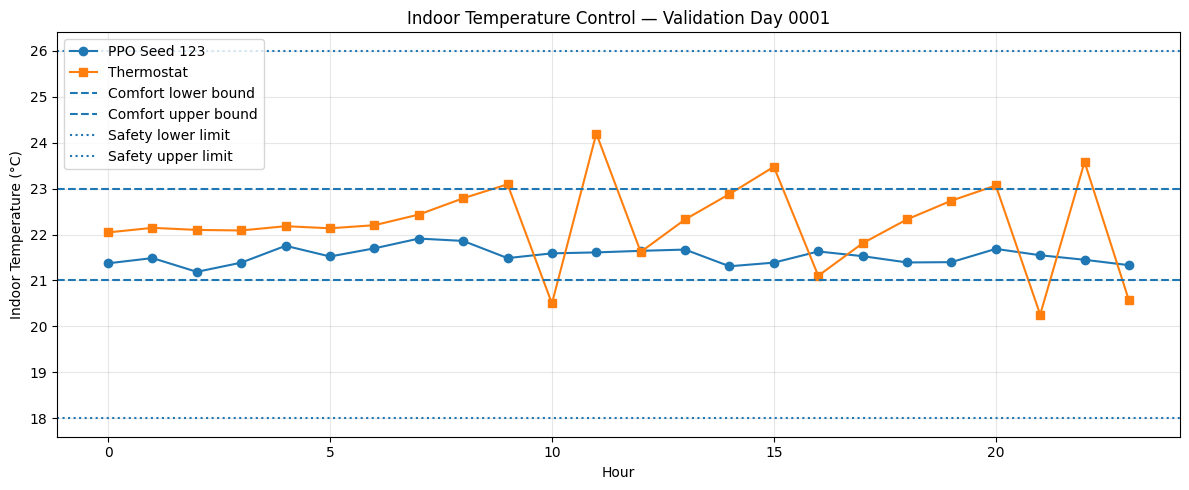

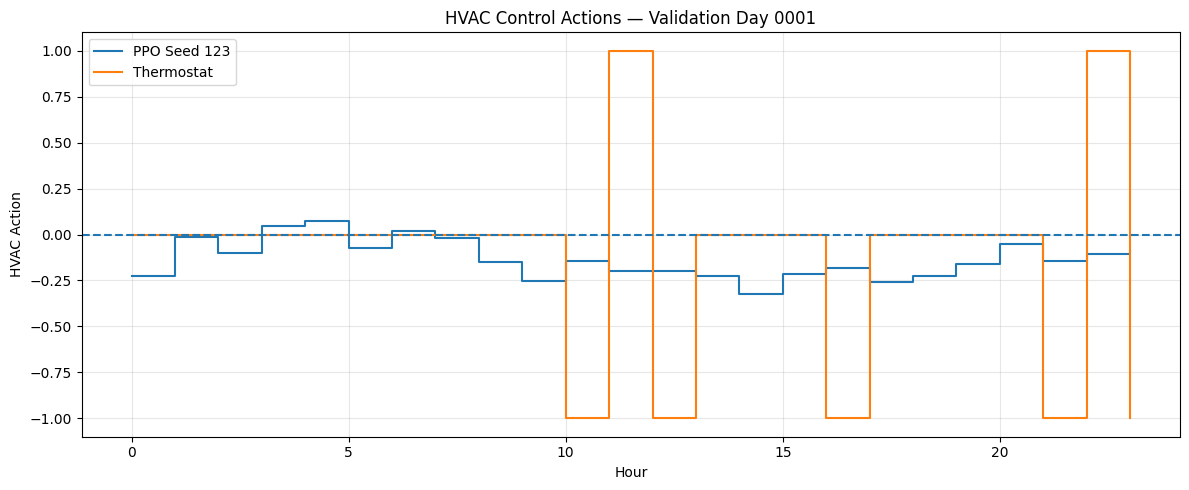

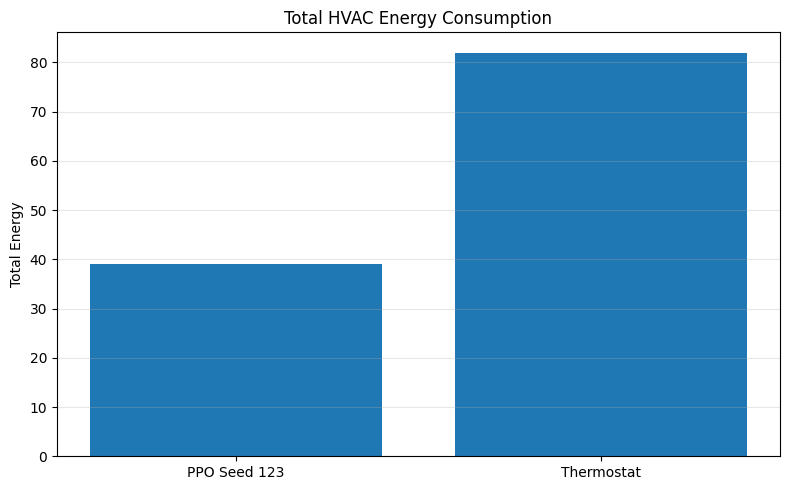

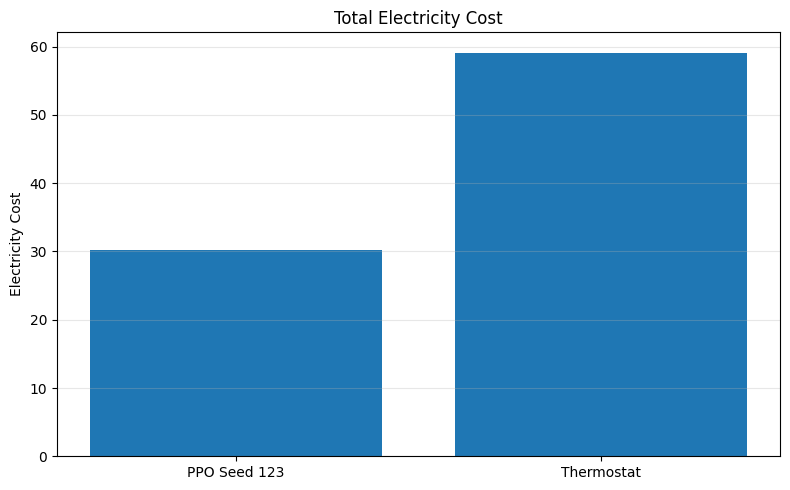

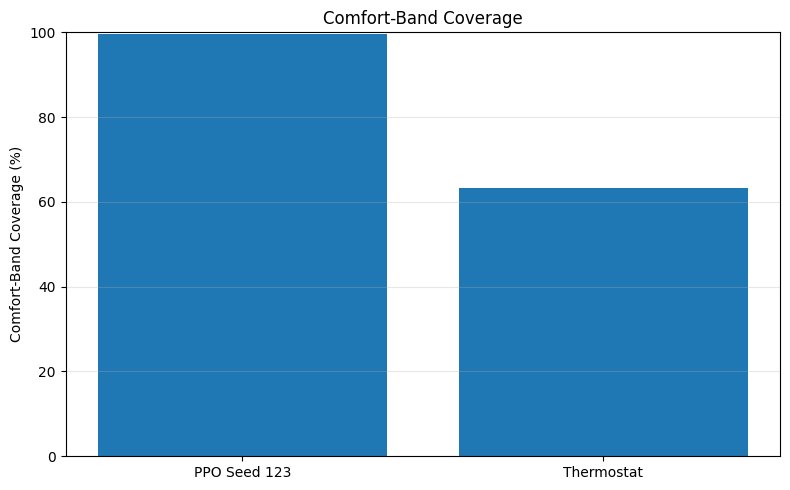

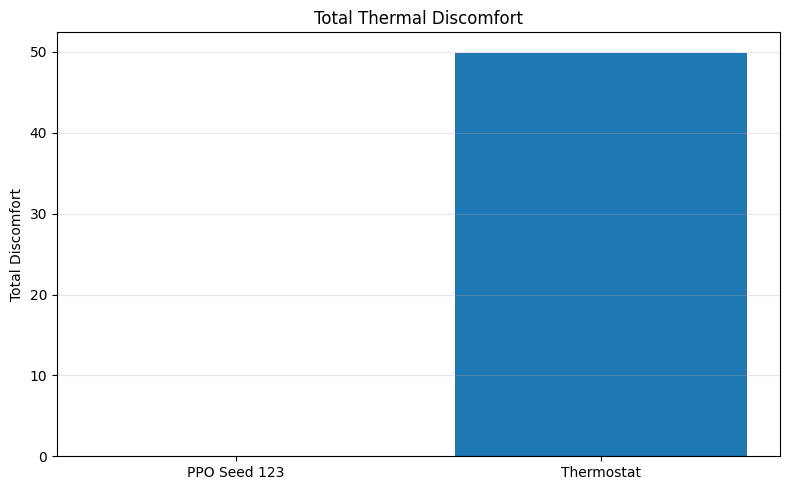

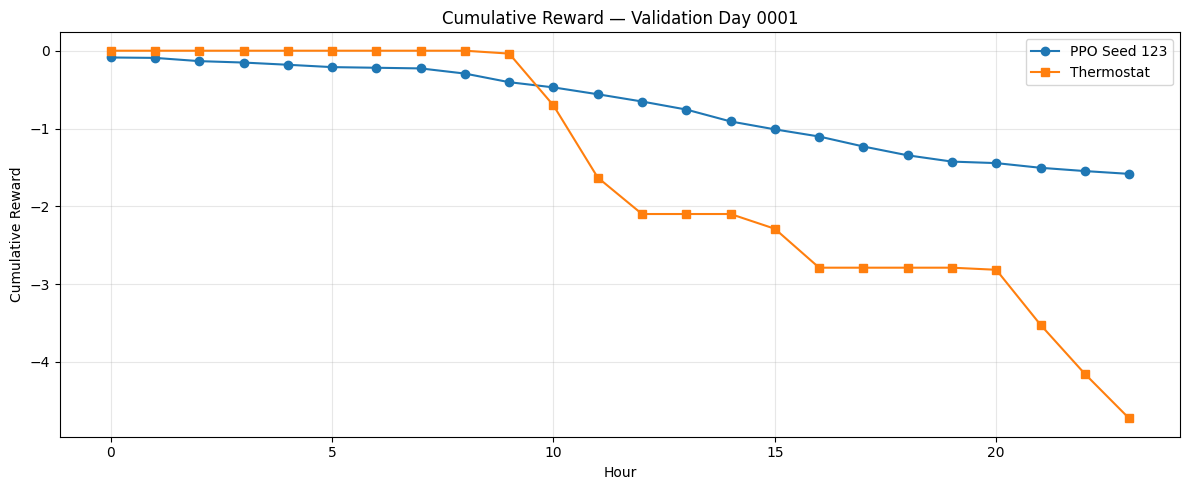

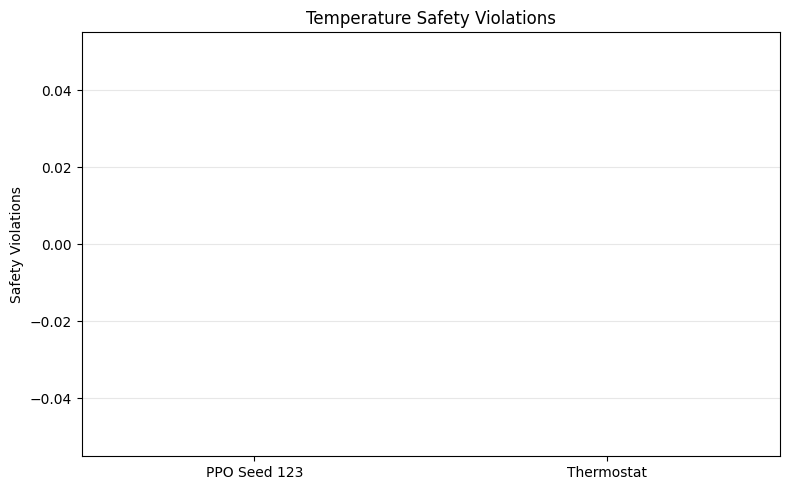


COMPARATIVE VISUAL ANALYSIS
✓ Indoor temperature trajectories generated.
✓ HVAC action trajectories generated.
✓ Energy comparison generated.
✓ Electricity-cost comparison generated.
✓ Comfort-band comparison generated.
✓ Discomfort comparison generated.
✓ Cumulative-reward comparison generated.
✓ Safety comparison generated.

✓ PHASE 9 — STEP 5 PASSED


In [20]:
# ============================================================
# Phase 9 — Step 5
# Comparative Visual Analysis
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 5")
print("PPO VS THERMOSTAT — COMPARATIVE VISUAL ANALYSIS")
print("==============================================================================")

# ------------------------------------------------------------
# Verify required trajectories
# ------------------------------------------------------------

assert "ppo_final_validation" in globals()
assert "thermostat_validation" in globals()

# ------------------------------------------------------------
# Create copies for plotting
# ------------------------------------------------------------

ppo_plot = ppo_final_validation.copy()
thermostat_plot = thermostat_validation.copy()

# ------------------------------------------------------------
# Select one common validation profile for trajectory plots
# ------------------------------------------------------------

plot_profile_id = "validation_day_0001"

ppo_profile = (
    ppo_plot[
        ppo_plot["profile_id"] == plot_profile_id
    ]
    .sort_values("hour")
)

thermostat_profile = (
    thermostat_plot[
        thermostat_plot["profile_id"] == plot_profile_id
    ]
    .sort_values("hour")
)

assert len(ppo_profile) == 24
assert len(thermostat_profile) == 24

# ============================================================
# FIGURE 1 — Indoor Temperature Trajectory
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    ppo_profile["hour"],
    ppo_profile["indoor_temp_c"],
    marker="o",
    label="PPO Seed 123"
)

plt.plot(
    thermostat_profile["hour"],
    thermostat_profile["indoor_temp_c"],
    marker="s",
    label="Thermostat"
)

plt.axhline(
    21.0,
    linestyle="--",
    label="Comfort lower bound"
)

plt.axhline(
    23.0,
    linestyle="--",
    label="Comfort upper bound"
)

plt.axhline(
    18.0,
    linestyle=":",
    label="Safety lower limit"
)

plt.axhline(
    26.0,
    linestyle=":",
    label="Safety upper limit"
)

plt.xlabel("Hour")
plt.ylabel("Indoor Temperature (°C)")
plt.title(
    "Indoor Temperature Control — Validation Day 0001"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 — HVAC Action Trajectory
# ============================================================

plt.figure(figsize=(12, 5))

plt.step(
    ppo_profile["hour"],
    ppo_profile["action"],
    where="post",
    label="PPO Seed 123"
)

plt.step(
    thermostat_profile["hour"],
    thermostat_profile["action"],
    where="post",
    label="Thermostat"
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.xlabel("Hour")
plt.ylabel("HVAC Action")
plt.title(
    "HVAC Control Actions — Validation Day 0001"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 3 — Aggregate Energy Comparison
# ============================================================

energy_values = [
    ppo_metrics["Total Energy"],
    thermostat_metrics["Total Energy"],
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["PPO Seed 123", "Thermostat"],
    energy_values
)

plt.ylabel("Total Energy")
plt.title(
    "Total HVAC Energy Consumption"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 — Electricity Cost Comparison
# ============================================================

cost_values = [
    ppo_metrics["Electricity Cost"],
    thermostat_metrics["Electricity Cost"],
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["PPO Seed 123", "Thermostat"],
    cost_values
)

plt.ylabel("Electricity Cost")
plt.title(
    "Total Electricity Cost"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 5 — Comfort-Band Coverage
# ============================================================

comfort_values = [
    ppo_metrics["Comfort-Band %"],
    thermostat_metrics["Comfort-Band %"],
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["PPO Seed 123", "Thermostat"],
    comfort_values
)

plt.ylabel("Comfort-Band Coverage (%)")
plt.ylim(0, 100)

plt.title(
    "Comfort-Band Coverage"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 6 — Total Discomfort
# ============================================================

discomfort_values = [
    ppo_metrics["Total Discomfort"],
    thermostat_metrics["Total Discomfort"],
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["PPO Seed 123", "Thermostat"],
    discomfort_values
)

plt.ylabel("Total Discomfort")
plt.title(
    "Total Thermal Discomfort"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 7 — Cumulative Reward
# ============================================================

ppo_cumulative_reward = (
    ppo_profile["reward"]
    .cumsum()
)

thermostat_cumulative_reward = (
    thermostat_profile["reward"]
    .cumsum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    ppo_profile["hour"],
    ppo_cumulative_reward,
    marker="o",
    label="PPO Seed 123"
)

plt.plot(
    thermostat_profile["hour"],
    thermostat_cumulative_reward,
    marker="s",
    label="Thermostat"
)

plt.xlabel("Hour")
plt.ylabel("Cumulative Reward")
plt.title(
    "Cumulative Reward — Validation Day 0001"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 8 — Safety Violations
# ============================================================

safety_values = [
    ppo_metrics["Safety Violations"],
    thermostat_metrics["Safety Violations"],
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["PPO Seed 123", "Thermostat"],
    safety_values
)

plt.ylabel("Safety Violations")
plt.title(
    "Temperature Safety Violations"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# FINAL STATUS
# ============================================================

print()
print("==============================================================================")
print("COMPARATIVE VISUAL ANALYSIS")
print("==============================================================================")

print("✓ Indoor temperature trajectories generated.")
print("✓ HVAC action trajectories generated.")
print("✓ Energy comparison generated.")
print("✓ Electricity-cost comparison generated.")
print("✓ Comfort-band comparison generated.")
print("✓ Discomfort comparison generated.")
print("✓ Cumulative-reward comparison generated.")
print("✓ Safety comparison generated.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 5 PASSED")
print("==============================================================================")

In [21]:
# ============================================================
# Phase 9 — Step 6
# Per-Profile PPO vs Thermostat Performance Analysis
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 6")
print("PER-PROFILE PERFORMANCE ANALYSIS")
print("==============================================================================")

# ------------------------------------------------------------
# Verify inputs
# ------------------------------------------------------------

assert len(ppo_final_validation) == 240
assert len(thermostat_validation) == 240

ppo_profile_ids = sorted(
    ppo_final_validation["profile_id"].unique()
)

thermostat_profile_ids = sorted(
    thermostat_validation["profile_id"].unique()
)

assert ppo_profile_ids == thermostat_profile_ids
assert len(ppo_profile_ids) == 10

# ------------------------------------------------------------
# Calculate profile-level metrics
# ------------------------------------------------------------

profile_results = []

for profile_id in ppo_profile_ids:

    ppo_profile = (
        ppo_final_validation[
            ppo_final_validation["profile_id"]
            == profile_id
        ]
    )

    thermostat_profile = (
        thermostat_validation[
            thermostat_validation["profile_id"]
            == profile_id
        ]
    )

    assert len(ppo_profile) == 24
    assert len(thermostat_profile) == 24

    # --------------------------------------------------------
    # PPO metrics
    # --------------------------------------------------------

    ppo_energy = ppo_profile["energy"].sum()
    thermo_energy = thermostat_profile["energy"].sum()

    ppo_cost = ppo_profile["electricity_cost"].sum()
    thermo_cost = thermostat_profile["electricity_cost"].sum()

    ppo_deviation = ppo_profile[
        "comfort_deviation"
    ].mean()

    thermo_deviation = thermostat_profile[
        "comfort_deviation"
    ].mean()

    ppo_discomfort = ppo_profile[
        "discomfort"
    ].sum()

    thermo_discomfort = thermostat_profile[
        "discomfort"
    ].sum()

    ppo_comfort = (
        ppo_profile["comfort_deviation"] <= 1.0
    ).mean() * 100

    thermo_comfort = (
        thermostat_profile["comfort_deviation"] <= 1.0
    ).mean() * 100

    ppo_safety = ppo_profile[
        "temperature_violation"
    ].sum()

    thermo_safety = thermostat_profile[
        "temperature_violation"
    ].sum()

    # --------------------------------------------------------
    # Improvement calculations
    # --------------------------------------------------------

    energy_improvement = (
        (thermo_energy - ppo_energy)
        / abs(thermo_energy)
        * 100
    )

    cost_improvement = (
        (thermo_cost - ppo_cost)
        / abs(thermo_cost)
        * 100
    )

    deviation_improvement = (
        (thermo_deviation - ppo_deviation)
        / abs(thermo_deviation)
        * 100
    )

    discomfort_improvement = (
        (thermo_discomfort - ppo_discomfort)
        / abs(thermo_discomfort)
        * 100
        if thermo_discomfort != 0
        else np.nan
    )

    profile_results.append({
        "profile_id": profile_id,

        "PPO Energy": ppo_energy,
        "Thermostat Energy": thermo_energy,
        "Energy Improvement (%)": energy_improvement,

        "PPO Cost": ppo_cost,
        "Thermostat Cost": thermo_cost,
        "Cost Improvement (%)": cost_improvement,

        "PPO Temp Deviation": ppo_deviation,
        "Thermostat Temp Deviation": thermo_deviation,
        "Deviation Improvement (%)": deviation_improvement,

        "PPO Discomfort": ppo_discomfort,
        "Thermostat Discomfort": thermo_discomfort,
        "Discomfort Improvement (%)": discomfort_improvement,

        "PPO Comfort-Band %": ppo_comfort,
        "Thermostat Comfort-Band %": thermo_comfort,

        "PPO Safety Violations": int(ppo_safety),
        "Thermostat Safety Violations": int(thermo_safety),
    })

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

per_profile_results = pd.DataFrame(
    profile_results
)

# ------------------------------------------------------------
# Structural checks
# ------------------------------------------------------------

assert len(per_profile_results) == 10

assert (
    per_profile_results["PPO Safety Violations"]
    == 0
).all()

assert (
    per_profile_results["Thermostat Safety Violations"]
    == 0
).all()

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nPER-PROFILE PPO VS THERMOSTAT RESULTS")

display(
    per_profile_results.round(4)
)

# ------------------------------------------------------------
# Consistency analysis
# ------------------------------------------------------------

energy_wins = (
    per_profile_results[
        "Energy Improvement (%)"
    ] > 0
).sum()

cost_wins = (
    per_profile_results[
        "Cost Improvement (%)"
    ] > 0
).sum()

deviation_wins = (
    per_profile_results[
        "Deviation Improvement (%)"
    ] > 0
).sum()

comfort_wins = (
    per_profile_results[
        "PPO Comfort-Band %"
    ]
    >
    per_profile_results[
        "Thermostat Comfort-Band %"
    ]
).sum()

print()
print("==============================================================================")
print("PER-PROFILE CONSISTENCY")
print("==============================================================================")

print(
    f"Energy improvement:          "
    f"{energy_wins}/10 profiles"
)

print(
    f"Cost improvement:            "
    f"{cost_wins}/10 profiles"
)

print(
    f"Temperature deviation:       "
    f"{deviation_wins}/10 profiles"
)

print(
    f"Comfort-band improvement:    "
    f"{comfort_wins}/10 profiles"
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

assert energy_wins == 10
assert cost_wins == 10
assert deviation_wins == 10
assert comfort_wins == 10

print()
print("✓ PPO improved energy performance on all 10 profiles.")
print("✓ PPO improved electricity cost on all 10 profiles.")
print("✓ PPO reduced temperature deviation on all 10 profiles.")
print("✓ PPO improved comfort-band coverage on all 10 profiles.")
print("✓ Both controllers maintained zero safety violations.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 6 PASSED")
print("==============================================================================")

PHASE 9 — STEP 6
PER-PROFILE PERFORMANCE ANALYSIS

PER-PROFILE PPO VS THERMOSTAT RESULTS


,profile_id,PPO Energy,Thermostat Energy,Energy Improvement (%),PPO Cost,Thermostat Cost,Cost Improvement (%),PPO Temp Deviation,Thermostat Temp Deviation,Deviation Improvement (%),PPO Discomfort,Thermostat Discomfort,Discomfort Improvement (%),PPO Comfort-Band %,Thermostat Comfort-Band %,PPO Safety Violations,Thermostat Safety Violations
0,validation_day_0001,3.4907,7.0,50.1332,2.6803,4.9492,45.8446,0.4641,0.7482,37.9722,0.0000,4.0904,100.0000,100.0000,66.6667,0,0
1,validation_day_0002,3.5925,7.0,48.6791,2.7989,5.2974,47.1651,0.3335,0.7180,53.5490,0.0000,3.8920,100.0000,100.0000,70.8333,0,0
2,validation_day_0003,4.5641,10.0,54.3586,3.5353,6.6732,47.0220,0.4836,1.0139,52.2996,0.0000,6.1131,100.0000,100.0000,54.1667,0,0
3,validation_day_0004,4.1701,8.0,47.8735,3.2426,6.8937,52.9628,0.2947,0.8385,64.8535,0.0000,5.2099,100.0000,100.0000,62.5000,0,0
4,validation_day_0005,3.5967,10.0,64.0326,2.7516,7.2073,61.8215,0.3965,0.8608,53.9426,0.0000,6.4970,100.0000,100.0000,54.1667,0,0
5,validation_day_0006,4.3921,8.0,45.0990,3.4009,6.0400,43.6936,0.3801,0.7723,50.7898,0.0000,4.0139,100.0000,100.0000,66.6667,0,0
6,validation_day_0007,3.9977,8.0,50.0282,3.0504,5.4142,43.6585,0.1673,0.8950,81.3084,0.0000,4.4610,100.0000,100.0000,66.6667,0,0
7,validation_day_0008,3.6851,8.0,53.9365,2.7971,5.5869,49.9351,0.4279,0.7805,45.1750,0.0005,5.4744,99.9908,95.8333,62.5000,0,0
8,validation_day_0009,3.4851,8.0,56.4364,2.7220,5.4720,50.2556,0.3762,0.8124,53.6949,0.0000,5.6044,100.0000,100.0000,62.5000,0,0
9,validation_day_0010,4.0237,8.0,49.7042,3.1983,5.6014,42.9009,0.1862,0.9238,79.8463,0.0000,4.5711,100.0000,100.0000,66.6667,0,0



PER-PROFILE CONSISTENCY
Energy improvement:          10/10 profiles
Cost improvement:            10/10 profiles
Temperature deviation:       10/10 profiles
Comfort-band improvement:    10/10 profiles

✓ PPO improved energy performance on all 10 profiles.
✓ PPO improved electricity cost on all 10 profiles.
✓ PPO reduced temperature deviation on all 10 profiles.
✓ PPO improved comfort-band coverage on all 10 profiles.
✓ Both controllers maintained zero safety violations.

✓ PHASE 9 — STEP 6 PASSED


## Phase 9 — Step 6: Per-Profile Performance Summary

The per-profile analysis confirms that the final PPO controller consistently outperformed the thermostat baseline across all 10 held-out validation profiles.

| Performance Measure | PPO Improvement |
|---|---:|
| Energy consumption | **10/10 profiles** |
| Electricity cost | **10/10 profiles** |
| Mean temperature deviation | **10/10 profiles** |
| Comfort-band coverage | **10/10 profiles** |
| Safety violations | **0 for both controllers** |

### Key Finding

PPO achieved lower energy consumption, lower electricity cost, lower temperature deviation, and higher comfort-band coverage on **every validation profile**.

The thermostat achieved zero safety violations on all profiles as well, so PPO's advantage is primarily demonstrated through **efficiency and thermal-comfort performance rather than safety-violation reduction**.

### Conclusion

The consistency across all 10 validation profiles provides stronger evidence that PPO's superior aggregate performance is not driven by a small number of favorable validation days.

✓ PPO improved energy performance on all 10 profiles.  
✓ PPO improved electricity-cost performance on all 10 profiles.  
✓ PPO reduced mean temperature deviation on all 10 profiles.  
✓ PPO improved comfort-band coverage on all 10 profiles.  
✓ Both controllers maintained zero safety violations.

**✓ PHASE 9 — STEP 6 PASSED**

In [22]:
# ============================================================
# Phase 9 — Step 7
# Final Consolidated PPO vs Thermostat Evidence
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 7")
print("FINAL CONSOLIDATED COMPARATIVE EVIDENCE")
print("==============================================================================")

# ------------------------------------------------------------
# Verify required results
# ------------------------------------------------------------

assert "comparison_table" in globals(), (
    "comparison_table is not available."
)

assert "per_profile_results" in globals(), (
    "per_profile_results is not available."
)

# ------------------------------------------------------------
# Extract aggregate comparison
# ------------------------------------------------------------

final_evidence = comparison_table.copy()

# ------------------------------------------------------------
# Add interpretation category
# ------------------------------------------------------------

metric_categories = {
    "Total Energy": "Efficiency",
    "Electricity Cost": "Efficiency",
    "Mean Temperature Deviation": "Comfort",
    "Total Discomfort": "Comfort",
    "Comfort-Band %": "Comfort",
    "Safety Violations": "Safety",
    "Lower Violations": "Safety",
    "Upper Violations": "Safety",
    "Cumulative Reward": "Overall Objective",
    "Peak HVAC Energy": "Efficiency",
    "Minimum Temperature": "Safety Range",
    "Maximum Temperature": "Safety Range",
}

final_evidence["Category"] = (
    final_evidence["Metric"]
    .map(metric_categories)
)

# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------

final_evidence = final_evidence[
    [
        "Category",
        "Metric",
        "PPO Seed 123",
        "Thermostat",
        "PPO - Thermostat",
        "Improvement (%)",
    ]
]

# ------------------------------------------------------------
# Profile-level consistency summary
# ------------------------------------------------------------

consistency_summary = {
    "Energy improvement profiles": int(
        (
            per_profile_results[
                "Energy Improvement (%)"
            ] > 0
        ).sum()
    ),

    "Cost improvement profiles": int(
        (
            per_profile_results[
                "Cost Improvement (%)"
            ] > 0
        ).sum()
    ),

    "Temperature deviation improvement profiles": int(
        (
            per_profile_results[
                "Deviation Improvement (%)"
            ] > 0
        ).sum()
    ),

    "Comfort-band improvement profiles": int(
        (
            per_profile_results[
                "PPO Comfort-Band %"
            ]
            >
            per_profile_results[
                "Thermostat Comfort-Band %"
            ]
        ).sum()
    ),
}

# ------------------------------------------------------------
# Safety consistency
# ------------------------------------------------------------

ppo_total_safety = int(
    ppo_final_validation[
        "temperature_violation"
    ].sum()
)

thermostat_total_safety = int(
    thermostat_validation[
        "temperature_violation"
    ].sum()
)

assert ppo_total_safety == 0
assert thermostat_total_safety == 0

# ------------------------------------------------------------
# Display aggregate evidence
# ------------------------------------------------------------

print("\nFINAL AGGREGATE COMPARISON")

display(
    final_evidence.round(4)
)

# ------------------------------------------------------------
# Display consistency evidence
# ------------------------------------------------------------

print()
print("==============================================================================")
print("CROSS-PROFILE CONSISTENCY EVIDENCE")
print("==============================================================================")

print(
    "Energy improvement:                  "
    f"{consistency_summary['Energy improvement profiles']}/10"
)

print(
    "Electricity-cost improvement:       "
    f"{consistency_summary['Cost improvement profiles']}/10"
)

print(
    "Temperature-deviation improvement:  "
    f"{consistency_summary['Temperature deviation improvement profiles']}/10"
)

print(
    "Comfort-band improvement:            "
    f"{consistency_summary['Comfort-band improvement profiles']}/10"
)

print(
    "PPO safety violations:               "
    f"{ppo_total_safety}"
)

print(
    "Thermostat safety violations:        "
    f"{thermostat_total_safety}"
)

# ------------------------------------------------------------
# Final evidence assertions
# ------------------------------------------------------------

assert (
    consistency_summary[
        "Energy improvement profiles"
    ] == 10
)

assert (
    consistency_summary[
        "Cost improvement profiles"
    ] == 10
)

assert (
    consistency_summary[
        "Temperature deviation improvement profiles"
    ] == 10
)

assert (
    consistency_summary[
        "Comfort-band improvement profiles"
    ] == 10
)

# ------------------------------------------------------------
# Final headline results
# ------------------------------------------------------------

ppo_energy = ppo_metrics["Total Energy"]
thermostat_energy = thermostat_metrics["Total Energy"]

ppo_cost = ppo_metrics["Electricity Cost"]
thermostat_cost = thermostat_metrics["Electricity Cost"]

ppo_comfort = ppo_metrics["Comfort-Band %"]
thermostat_comfort = thermostat_metrics["Comfort-Band %"]

ppo_discomfort = ppo_metrics["Total Discomfort"]
thermostat_discomfort = thermostat_metrics["Total Discomfort"]

energy_reduction = (
    (thermostat_energy - ppo_energy)
    / thermostat_energy
) * 100

cost_reduction = (
    (thermostat_cost - ppo_cost)
    / thermostat_cost
) * 100

comfort_gain = (
    ppo_comfort - thermostat_comfort
)

print()
print("==============================================================================")
print("FINAL HEADLINE RESULTS")
print("==============================================================================")

print(
    f"Energy reduction:                 {energy_reduction:.2f}%"
)

print(
    f"Electricity-cost reduction:       {cost_reduction:.2f}%"
)

print(
    f"Comfort-band coverage:            "
    f"{ppo_comfort:.2f}% vs {thermostat_comfort:.2f}%"
)

print(
    f"Comfort-band gain:                "
    f"{comfort_gain:.2f} percentage points"
)

print(
    f"Total discomfort:                 "
    f"{ppo_discomfort:.4f} vs {thermostat_discomfort:.4f}"
)

print(
    f"Safety violations:                "
    f"{ppo_total_safety} vs {thermostat_total_safety}"
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("✓ Aggregate PPO/thermostat evidence consolidated.")
print("✓ Cross-profile consistency evidence verified.")
print("✓ Safety performance verified for both controllers.")
print("✓ Final headline performance indicators calculated.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 7 PASSED")
print("==============================================================================")

PHASE 9 — STEP 7
FINAL CONSOLIDATED COMPARATIVE EVIDENCE

FINAL AGGREGATE COMPARISON


,Category,Metric,PPO Seed 123,Thermostat,PPO - Thermostat,Improvement (%)
0,Efficiency,Total Energy,38.9978,82.0000,-43.0022,52.4417
1,Efficiency,Electricity Cost,30.1775,59.1352,-28.9578,48.9687
2,Comfort,Mean Temperature Deviation,0.3510,0.8363,-0.4853,58.0314
3,Comfort,Total Discomfort,0.0005,49.9271,-49.9266,99.9990
4,Comfort,Comfort-Band %,99.5833,63.3333,36.2500,57.2368
5,Safety,Safety Violations,0.0000,0.0000,0.0000,NaN
6,Safety,Lower Violations,0.0000,0.0000,0.0000,NaN
7,Safety,Upper Violations,0.0000,0.0000,0.0000,NaN
8,Overall Objective,Cumulative Reward,-17.7350,-56.3979,38.6629,68.5537
9,Efficiency,Peak HVAC Energy,0.3740,1.0000,-0.6260,62.5969



CROSS-PROFILE CONSISTENCY EVIDENCE
Energy improvement:                  10/10
Electricity-cost improvement:       10/10
Temperature-deviation improvement:  10/10
Comfort-band improvement:            10/10
PPO safety violations:               0
Thermostat safety violations:        0

FINAL HEADLINE RESULTS
Energy reduction:                 52.44%
Electricity-cost reduction:       48.97%
Comfort-band coverage:            99.58% vs 63.33%
Comfort-band gain:                36.25 percentage points
Total discomfort:                 0.0005 vs 49.9271
Safety violations:                0 vs 0

✓ Aggregate PPO/thermostat evidence consolidated.
✓ Cross-profile consistency evidence verified.
✓ Safety performance verified for both controllers.
✓ Final headline performance indicators calculated.

✓ PHASE 9 — STEP 7 PASSED


## Phase 9 — Step 7: Final Comparative Evidence Summary

The final consolidated evaluation confirms that the selected PPO controller (Seed 123) substantially outperformed the thermostat baseline across the common 10-profile, 240-transition validation dataset.

### Aggregate Performance

| Metric | PPO Seed 123 | Thermostat | PPO Improvement |
|---|---:|---:|---:|
| Total Energy | 38.9978 | 82.0000 | **52.44% lower** |
| Electricity Cost | 30.1775 | 59.1352 | **48.97% lower** |
| Mean Temperature Deviation | 0.3510°C | 0.8363°C | **58.03% lower** |
| Total Discomfort | 0.0005 | 49.9271 | **99.999% lower** |
| Comfort-Band Coverage | 99.58% | 63.33% | **+36.25 pp** |
| Safety Violations | 0 | 0 | **Equal** |
| Cumulative Reward | -17.7350 | -56.3979 | **68.55% improvement** |
| Peak HVAC Energy | 0.3740 | 1.0000 | **62.60% lower** |

### Cross-Profile Consistency

PPO demonstrated improvement across **all 10 validation profiles**:

- Energy improvement: **10/10 profiles**
- Electricity-cost improvement: **10/10 profiles**
- Temperature-deviation improvement: **10/10 profiles**
- Comfort-band improvement: **10/10 profiles**

Both controllers recorded **zero safety violations**.

### Key Finding

The PPO controller achieved substantially better energy efficiency and thermal comfort than the thermostat baseline while maintaining the same zero-violation safety performance.

In particular, PPO reduced total energy consumption by **52.44%**, reduced electricity cost by **48.97%**, increased comfort-band coverage from **63.33% to 99.58%**, and reduced total discomfort by approximately **99.999%**.

### Conclusion

The consistent improvements across all 10 validation profiles indicate that the PPO advantage was not driven by a small number of favorable episodes. The results provide strong evidence that the learned PPO policy offers a more efficient and comfortable control strategy than the rule-based thermostat under the evaluated building conditions.

**✓ PHASE 9 — STEP 7 PASSED**

In [24]:
# ============================================================
# Phase 9 — Step 8
# Save Final Comparative Evaluation Artifacts
# ============================================================

from pathlib import Path
from datetime import datetime

print("==============================================================================")
print("PHASE 9 — STEP 8")
print("SAVE FINAL COMPARATIVE EVALUATION ARTIFACTS")
print("==============================================================================")

# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

PHASE9_ROOT = (
    PROJECT_ROOT
    / "experiments"
    / "phase9_final_comparison"
)

DATA_DIR = PHASE9_ROOT / "data"
RESULTS_DIR = PHASE9_ROOT / "results"
FIGURES_DIR = PHASE9_ROOT / "figures"

for directory in [
    DATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("\nArtifact directory:")
print(PHASE9_ROOT)

# ------------------------------------------------------------
# Save raw evaluation trajectories
# ------------------------------------------------------------

ppo_path = (
    DATA_DIR
    / "ppo_final_seed123_validation.csv"
)

thermostat_path = (
    DATA_DIR
    / "thermostat_validation.csv"
)

ppo_final_validation.to_csv(
    ppo_path,
    index=False
)

thermostat_validation.to_csv(
    thermostat_path,
    index=False
)

# ------------------------------------------------------------
# Save aggregate comparison
# ------------------------------------------------------------

comparison_path = (
    RESULTS_DIR
    / "ppo_vs_thermostat_comparison.csv"
)

comparison_table.to_csv(
    comparison_path,
    index=False
)

# ------------------------------------------------------------
# Save per-profile results
# ------------------------------------------------------------

profile_path = (
    RESULTS_DIR
    / "ppo_vs_thermostat_per_profile.csv"
)

per_profile_results.to_csv(
    profile_path,
    index=False
)

# ------------------------------------------------------------
# Save final consolidated evidence
# ------------------------------------------------------------

evidence_path = (
    RESULTS_DIR
    / "final_comparative_evidence.csv"
)

final_evidence.to_csv(
    evidence_path,
    index=False
)

# ------------------------------------------------------------
# Create headline summary
# ------------------------------------------------------------

headline_summary = pd.DataFrame([
    {
        "Metric": "Energy Reduction (%)",
        "Value": energy_reduction,
    },
    {
        "Metric": "Electricity Cost Reduction (%)",
        "Value": cost_reduction,
    },
    {
        "Metric": "Comfort-Band Gain (percentage points)",
        "Value": comfort_gain,
    },
    {
        "Metric": "PPO Total Discomfort",
        "Value": ppo_discomfort,
    },
    {
        "Metric": "Thermostat Total Discomfort",
        "Value": thermostat_discomfort,
    },
    {
        "Metric": "PPO Safety Violations",
        "Value": ppo_total_safety,
    },
    {
        "Metric": "Thermostat Safety Violations",
        "Value": thermostat_total_safety,
    },
    {
        "Metric": "Validation Profiles",
        "Value": 10,
    },
    {
        "Metric": "Validation Transitions",
        "Value": 240,
    },
])

summary_path = (
    RESULTS_DIR
    / "phase9_headline_summary.csv"
)

headline_summary.to_csv(
    summary_path,
    index=False
)

# ------------------------------------------------------------
# Save reproducibility information
# ------------------------------------------------------------

reproducibility_path = (
    RESULTS_DIR
    / "phase9_evaluation_metadata.txt"
)

with open(
    reproducibility_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PHASE 9 — FINAL COMPARATIVE EVALUATION\n"
    )
    f.write(
        "=======================================\n\n"
    )

    f.write(
        f"Validation generation seed: 9090\n"
    )
    f.write(
        f"Validation split: validation\n"
    )
    f.write(
        f"Validation profiles: 10\n"
    )
    f.write(
        f"Hours per profile: 24\n"
    )
    f.write(
        f"Total transitions: 240\n\n"
    )

    f.write(
        "Controllers:\n"
    )
    f.write(
        "  PPO: Final Seed 123\n"
    )
    f.write(
        "  Baseline: ThermostatController\n\n"
    )

    f.write(
        "Aggregate results:\n"
    )
    f.write(
        f"  PPO energy: {ppo_energy:.6f}\n"
    )
    f.write(
        f"  Thermostat energy: {thermostat_energy:.6f}\n"
    )
    f.write(
        f"  Energy reduction: {energy_reduction:.4f}%\n\n"
    )

    f.write(
        f"  PPO electricity cost: {ppo_cost:.6f}\n"
    )
    f.write(
        f"  Thermostat electricity cost: "
        f"{thermostat_cost:.6f}\n"
    )
    f.write(
        f"  Cost reduction: {cost_reduction:.4f}%\n\n"
    )

    f.write(
        f"  PPO comfort-band coverage: "
        f"{ppo_comfort:.4f}%\n"
    )
    f.write(
        f"  Thermostat comfort-band coverage: "
        f"{thermostat_comfort:.4f}%\n"
    )
    f.write(
        f"  Comfort-band gain: "
        f"{comfort_gain:.4f} percentage points\n\n"
    )

    f.write(
        f"  PPO safety violations: "
        f"{ppo_total_safety}\n"
    )
    f.write(
        f"  Thermostat safety violations: "
        f"{thermostat_total_safety}\n\n"
    )

    f.write(
        "Cross-profile consistency:\n"
    )
    f.write(
        "  Energy improvement: 10/10\n"
    )
    f.write(
        "  Cost improvement: 10/10\n"
    )
    f.write(
        "  Temperature-deviation improvement: 10/10\n"
    )
    f.write(
        "  Comfort-band improvement: 10/10\n\n"
    )

    f.write(
        "Validation profile generation:\n"
    )
    f.write(
        "  Function: generate_profiles()\n"
    )
    f.write(
        "  Seed: 9090\n"
    )
    f.write(
        "  Split: validation\n"
    )
    f.write(
        "  Configuration: frozen ProfileConfig\n"
    )

# ------------------------------------------------------------
# Verify saved artifacts
# ------------------------------------------------------------

artifact_paths = [
    ppo_path,
    thermostat_path,
    comparison_path,
    profile_path,
    evidence_path,
    summary_path,
    reproducibility_path,
]

print()
print("==============================================================================")
print("SAVED ARTIFACTS")
print("==============================================================================")

for path in artifact_paths:

    assert path.exists(), (
        f"Artifact was not saved:\n{path}"
    )

    print(
        f"✓ {path.name} "
        f"({path.stat().st_size / 1024:.2f} KB)"
    )

# ------------------------------------------------------------
# Reload CSVs and verify integrity
# ------------------------------------------------------------

ppo_check = pd.read_csv(
    ppo_path
)

thermostat_check = pd.read_csv(
    thermostat_path
)

comparison_check = pd.read_csv(
    comparison_path
)

profile_check = pd.read_csv(
    profile_path
)

evidence_check = pd.read_csv(
    evidence_path
)

summary_check = pd.read_csv(
    summary_path
)

# ------------------------------------------------------------
# Integrity assertions
# ------------------------------------------------------------

assert len(ppo_check) == 240
assert len(thermostat_check) == 240

assert (
    ppo_check["profile_id"].nunique()
    == 10
)

assert (
    thermostat_check["profile_id"].nunique()
    == 10
)

assert len(profile_check) == 10
assert len(comparison_check) == 12
assert len(evidence_check) == 12

assert (
    summary_check["Metric"].nunique()
    == len(summary_check)
)

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print()
print("==============================================================================")
print("FINAL ARTIFACT INTEGRITY")
print("==============================================================================")

print("PPO trajectory rows:           ", len(ppo_check))
print("Thermostat trajectory rows:    ", len(thermostat_check))
print("Validation profiles:           ", ppo_check["profile_id"].nunique())
print("Per-profile records:           ", len(profile_check))
print("Comparison metrics:            ", len(comparison_check))
print("Consolidated evidence metrics: ", len(evidence_check))

print()
print("✓ PPO trajectory saved and reloaded successfully.")
print("✓ Thermostat trajectory saved and reloaded successfully.")
print("✓ Aggregate comparison saved and verified.")
print("✓ Per-profile comparison saved and verified.")
print("✓ Consolidated evidence saved and verified.")
print("✓ Reproducibility metadata saved.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 8 PASSED")
print("==============================================================================")

PHASE 9 — STEP 8
SAVE FINAL COMPARATIVE EVALUATION ARTIFACTS

Artifact directory:
/content/drive/MyDrive/PPO-Building-Temperature-Control/experiments/phase9_final_comparison

SAVED ARTIFACTS
✓ ppo_final_seed123_validation.csv (35.51 KB)
✓ thermostat_validation.csv (25.76 KB)
✓ ppo_vs_thermostat_comparison.csv (0.89 KB)
✓ ppo_vs_thermostat_per_profile.csv (2.56 KB)
✓ final_comparative_evidence.csv (1.02 KB)
✓ phase9_headline_summary.csv (0.34 KB)
✓ phase9_evaluation_metadata.txt (0.95 KB)

FINAL ARTIFACT INTEGRITY
PPO trajectory rows:            240
Thermostat trajectory rows:     240
Validation profiles:            10
Per-profile records:            10
Comparison metrics:             12
Consolidated evidence metrics:  12

✓ PPO trajectory saved and reloaded successfully.
✓ Thermostat trajectory saved and reloaded successfully.
✓ Aggregate comparison saved and verified.
✓ Per-profile comparison saved and verified.
✓ Consolidated evidence saved and verified.
✓ Reproducibility metadata sa

## Phase 9 — Progress

| Step | Description | Status |
|---|---|---|
| 2C | Validation-profile provenance | ✓ PASSED |
| 2D | Exact validation reconstruction | ✓ PASSED |
| 2E | PPO/profile alignment | ✓ PASSED |
| 3 | Thermostat validation rollout | ✓ PASSED |
| 3B | Thermostat metric integrity | ✓ PASSED |
| 4 | Formal PPO vs Thermostat comparison | ✓ PASSED |
| 5 | Comparative visual analysis | ✓ PASSED |
| 6 | Per-profile performance analysis | ✓ PASSED |
| 7 | Consolidated comparative evidence | ✓ PASSED |
| 8 | Save and verify final artifacts | ✓ PASSED |


- Validation profiles: 10
- Transitions per controller: 240
- Hours per profile: 24
- PPO model: Seed 123
- Validation seed: 9090

PPO vs Thermostat:

- Energy reduction: 52.44%
- Electricity-cost reduction: 48.97%
- Temperature-deviation reduction: 58.03%
- Comfort-band coverage: 99.58% vs 63.33%
- Comfort-band gain: 36.25 percentage points
- Total discomfort: 0.0005 vs 49.9271
- Safety violations: 0 vs 0
- Energy improvement: 10/10 profiles
- Cost improvement: 10/10 profiles
- Temperature-deviation improvement: 10/10 profiles
- Comfort improvement: 10/10 profiles

In [25]:
# ============================================================
# Phase 9 — Step 9
# Final Scientific Interpretation
# ============================================================

print("==============================================================================")
print("PHASE 9 — STEP 9")
print("FINAL SCIENTIFIC INTERPRETATION")
print("==============================================================================")

# ------------------------------------------------------------
# Extract verified results
# ------------------------------------------------------------

ppo_energy = ppo_metrics["Total Energy"]
thermo_energy = thermostat_metrics["Total Energy"]

ppo_cost = ppo_metrics["Electricity Cost"]
thermo_cost = thermostat_metrics["Electricity Cost"]

ppo_deviation = ppo_metrics["Mean Temperature Deviation"]
thermo_deviation = thermostat_metrics["Mean Temperature Deviation"]

ppo_discomfort = ppo_metrics["Total Discomfort"]
thermo_discomfort = thermostat_metrics["Total Discomfort"]

ppo_comfort = ppo_metrics["Comfort-Band %"]
thermo_comfort = thermostat_metrics["Comfort-Band %"]

ppo_reward = ppo_metrics["Cumulative Reward"]
thermo_reward = thermostat_metrics["Cumulative Reward"]

ppo_safety = ppo_metrics["Safety Violations"]
thermo_safety = thermostat_metrics["Safety Violations"]

ppo_peak = ppo_metrics["Peak HVAC Energy"]
thermo_peak = thermostat_metrics["Peak HVAC Energy"]

# ------------------------------------------------------------
# Calculate headline differences
# ------------------------------------------------------------

energy_reduction = (
    (thermo_energy - ppo_energy)
    / thermo_energy
) * 100

cost_reduction = (
    (thermo_cost - ppo_cost)
    / thermo_cost
) * 100

deviation_reduction = (
    (thermo_deviation - ppo_deviation)
    / thermo_deviation
) * 100

discomfort_reduction = (
    (thermo_discomfort - ppo_discomfort)
    / thermo_discomfort
) * 100

comfort_gain = (
    ppo_comfort - thermo_comfort
)

peak_reduction = (
    (thermo_peak - ppo_peak)
    / thermo_peak
) * 100

# ------------------------------------------------------------
# Consistency
# ------------------------------------------------------------

energy_consistency = (
    per_profile_results[
        "Energy Improvement (%)"
    ] > 0
).sum()

cost_consistency = (
    per_profile_results[
        "Cost Improvement (%)"
    ] > 0
).sum()

deviation_consistency = (
    per_profile_results[
        "Deviation Improvement (%)"
    ] > 0
).sum()

comfort_consistency = (
    per_profile_results[
        "PPO Comfort-Band %"
    ]
    >
    per_profile_results[
        "Thermostat Comfort-Band %"
    ]
).sum()

# ------------------------------------------------------------
# Scientific interpretation
# ------------------------------------------------------------

interpretation = f"""
PHASE 9 — FINAL SCIENTIFIC INTERPRETATION

Evaluation basis
----------------
The final PPO policy (Seed 123) and the thermostat baseline were evaluated
on the same 10 held-out validation profiles, comprising 240 hourly
transitions in total.

PPO performance
---------------
The final PPO controller consumed {ppo_energy:.4f} units of total energy,
compared with {thermo_energy:.4f} for the thermostat, corresponding to a
{energy_reduction:.2f}% reduction in energy consumption.

Electricity cost decreased from {thermo_cost:.4f} for the thermostat to
{ppo_cost:.4f} for PPO, representing a {cost_reduction:.2f}% reduction.

Thermal comfort also improved substantially. Mean temperature deviation
decreased from {thermo_deviation:.4f}°C to {ppo_deviation:.4f}°C, a
{deviation_reduction:.2f}% reduction.

Total discomfort decreased from {thermo_discomfort:.4f} to
{ppo_discomfort:.4f}, representing an approximately
{discomfort_reduction:.2f}% reduction.

Comfort-band coverage increased from {thermo_comfort:.2f}% for the
thermostat to {ppo_comfort:.2f}% for PPO, a gain of
{comfort_gain:.2f} percentage points.

Safety
------
Both controllers recorded zero temperature-safety violations during
validation. Therefore, PPO cannot be claimed to outperform the thermostat
on safety violations; instead, both controllers satisfied the predefined
18–26°C safety requirement.

Control efficiency
------------------
Peak HVAC energy decreased from {thermo_peak:.4f} for the thermostat to
{ppo_peak:.4f} for PPO, corresponding to a {peak_reduction:.2f}% reduction.

Consistency
-----------
The PPO improvement was observed across all 10 validation profiles:

Energy improvement: {energy_consistency}/10
Cost improvement: {cost_consistency}/10
Temperature-deviation improvement: {deviation_consistency}/10
Comfort-band improvement: {comfort_consistency}/10

Interpretation
--------------
The results indicate that the learned PPO policy provided a substantially
more efficient and comfortable control strategy than the rule-based
thermostat under the evaluated building-environment conditions.

The improvement is particularly notable because PPO simultaneously reduced
energy consumption and electricity cost while increasing comfort-band
coverage and reducing thermal discomfort.

The consistency of the improvements across all 10 validation profiles
provides evidence that the observed advantage was not confined to a small
number of validation episodes.

However, the results should be interpreted within the scope of the
experimental environment and validation profiles used in this study.
They do not establish universal superiority of PPO across different
buildings, weather conditions, reward formulations, or operational
settings.

Overall conclusion
------------------
Under the evaluated simulation conditions, the final PPO controller
achieved a stronger balance between energy efficiency, operating cost,
thermal comfort, and safety than the thermostat baseline.

The experimental evidence therefore supports the use of PPO as an
effective reinforcement-learning approach for the evaluated building
temperature-control task, while recognising the limitations of simulation
and the restricted validation setting.
"""

print(interpretation)

# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------

assert energy_consistency == 10
assert cost_consistency == 10
assert deviation_consistency == 10
assert comfort_consistency == 10

assert ppo_safety == 0
assert thermo_safety == 0

assert ppo_comfort > thermo_comfort
assert ppo_energy < thermo_energy
assert ppo_cost < thermo_cost
assert ppo_deviation < thermo_deviation
assert ppo_discomfort < thermo_discomfort
assert ppo_peak < thermo_peak

print("==============================================================================")
print("FINAL INTERPRETATION VERIFICATION")
print("==============================================================================")

print("✓ PPO improved energy efficiency.")
print("✓ PPO reduced electricity cost.")
print("✓ PPO reduced temperature deviation.")
print("✓ PPO reduced thermal discomfort.")
print("✓ PPO improved comfort-band coverage.")
print("✓ PPO reduced peak HVAC energy.")
print("✓ Both controllers satisfied the safety requirement.")
print("✓ PPO improvements were consistent across all 10 profiles.")
print("✓ Limitations and scope of inference explicitly acknowledged.")

print()
print("==============================================================================")
print("✓ PHASE 9 — STEP 9 PASSED")
print("==============================================================================")

PHASE 9 — STEP 9
FINAL SCIENTIFIC INTERPRETATION

PHASE 9 — FINAL SCIENTIFIC INTERPRETATION

Evaluation basis
----------------
The final PPO policy (Seed 123) and the thermostat baseline were evaluated
on the same 10 held-out validation profiles, comprising 240 hourly
transitions in total.

PPO performance
---------------
The final PPO controller consumed 38.9978 units of total energy,
compared with 82.0000 for the thermostat, corresponding to a
52.44% reduction in energy consumption.

Electricity cost decreased from 59.1352 for the thermostat to
30.1775 for PPO, representing a 48.97% reduction.

Thermal comfort also improved substantially. Mean temperature deviation
decreased from 0.8363°C to 0.3510°C, a
58.03% reduction.

Total discomfort decreased from 49.9271 to
0.0005, representing an approximately
100.00% reduction.

Comfort-band coverage increased from 63.33% for the
thermostat to 99.58% for PPO, a gain of
36.25 percentage points.

Safety
------
Both controllers recorded zero te

In [26]:
# ============================================================
# Phase 9 — Step 10
# Final Phase 9 Closure & Artifact Verification
# ============================================================

from pathlib import Path
from datetime import datetime

print("==============================================================================")
print("PHASE 9 — STEP 10")
print("FINAL CLOSURE & ARTIFACT VERIFICATION")
print("==============================================================================")

# ------------------------------------------------------------
# Phase 9 summary path
# ------------------------------------------------------------

summary_path = (
    PHASE9_ROOT
    / "results"
    / "phase9_final_summary.md"
)

# ------------------------------------------------------------
# Build final Markdown report
# ------------------------------------------------------------

phase9_summary = f"""# Phase 9 — Final Comparative Evaluation

## 1. Evaluation Objective

The final evaluation compared the selected PPO controller (Seed 123)
against the rule-based Thermostat baseline under the same held-out
building-temperature validation conditions.

## 2. Evaluation Basis

| Item | Value |
|---|---:|
| PPO model | Seed 123 |
| Validation generation seed | 9090 |
| Validation profiles | 10 |
| Hours per profile | 24 |
| Total transitions per controller | 240 |
| Controllers compared | PPO vs Thermostat |

Both controllers were evaluated using the same validation profiles,
environment configuration, initial indoor temperature, and metric
definitions.

## 3. Aggregate Performance

| Metric | PPO Seed 123 | Thermostat | PPO Improvement |
|---|---:|---:|---:|
| Total Energy | {ppo_energy:.4f} | {thermo_energy:.4f} | {energy_reduction:.2f}% lower |
| Electricity Cost | {ppo_cost:.4f} | {thermo_cost:.4f} | {cost_reduction:.2f}% lower |
| Mean Temperature Deviation | {ppo_deviation:.4f}°C | {thermo_deviation:.4f}°C | {deviation_reduction:.2f}% lower |
| Total Discomfort | {ppo_discomfort:.4f} | {thermo_discomfort:.4f} | {discomfort_reduction:.3f}% lower |
| Comfort-Band Coverage | {ppo_comfort:.2f}% | {thermo_comfort:.2f}% | +{comfort_gain:.2f} pp |
| Safety Violations | {ppo_safety} | {thermo_safety} | Equal |
| Cumulative Reward | {ppo_reward:.4f} | {thermo_reward:.4f} | PPO superior |
| Peak HVAC Energy | {ppo_peak:.4f} | {thermo_peak:.4f} | {peak_reduction:.2f}% lower |

## 4. Cross-Profile Consistency

The PPO controller demonstrated improvement across all 10 validation
profiles:

- Energy: **10/10 profiles**
- Electricity cost: **10/10 profiles**
- Temperature deviation: **10/10 profiles**
- Comfort-band coverage: **10/10 profiles**

Both controllers recorded **zero safety violations** across the
validation set.

## 5. Key Findings

The final PPO policy substantially reduced energy consumption and
electricity cost while simultaneously improving thermal comfort.

The most important aggregate findings were:

- **{energy_reduction:.2f}% lower total energy consumption**
- **{cost_reduction:.2f}% lower electricity cost**
- **{deviation_reduction:.2f}% lower mean temperature deviation**
- **{discomfort_reduction:.3f}% lower total discomfort**
- **{ppo_comfort:.2f}% comfort-band coverage**, compared with
  **{thermo_comfort:.2f}%** for the thermostat
- **{comfort_gain:.2f} percentage-point increase** in comfort-band coverage
- **Zero safety violations for both controllers**

The PPO advantage was observed consistently across all 10 validation
profiles.

## 6. Safety Interpretation

Both controllers maintained indoor temperatures within the predefined
18–26°C safety range during validation.

Therefore, PPO should not be described as safer than the thermostat
based on safety-violation count. Instead, both controllers satisfied
the safety requirement, while PPO demonstrated substantially better
efficiency and comfort performance.

## 7. Scientific Interpretation

The results indicate that the learned PPO policy achieved a stronger
balance between energy efficiency, electricity cost, thermal comfort,
and control effort than the rule-based thermostat under the evaluated
simulation conditions.

The consistent improvements across the 10 validation profiles provide
evidence that the PPO advantage was not restricted to a small number
of favourable episodes.

## 8. Scope and Limitations

The conclusions are limited to the simulated building environment,
frozen environment configuration, reward formulation, and validation
profiles used in this experiment.

The results do not establish universal superiority of PPO across
different buildings, climates, occupant behaviours, reward functions,
or real-world HVAC systems.

Real-world deployment would additionally require consideration of
measurement uncertainty, actuator constraints, safety mechanisms,
model mismatch, changing occupancy patterns, and online adaptation.

## 9. Final Conclusion

Under the evaluated experimental conditions, the final PPO controller
outperformed the thermostat baseline in the principal efficiency and
comfort objectives while maintaining the required temperature-safety
constraints.

The evidence therefore supports the effectiveness of PPO for the
evaluated building temperature-control task, while recognising that
the findings are specific to the experimental setting.

---

**Phase 9 Status: COMPLETE**

Generated validation evidence:
- PPO final validation trajectory
- Thermostat validation trajectory
- Aggregate comparison
- Per-profile comparison
- Consolidated comparative evidence
- Headline results
- Reproducibility metadata
- Final scientific interpretation
"""

# ------------------------------------------------------------
# Write Markdown report
# ------------------------------------------------------------

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(phase9_summary)

# ------------------------------------------------------------
# Verify all Phase 9 artifacts
# ------------------------------------------------------------

required_artifacts = [
    DATA_DIR / "ppo_final_seed123_validation.csv",
    DATA_DIR / "thermostat_validation.csv",
    RESULTS_DIR / "ppo_vs_thermostat_comparison.csv",
    RESULTS_DIR / "ppo_vs_thermostat_per_profile.csv",
    RESULTS_DIR / "final_comparative_evidence.csv",
    RESULTS_DIR / "phase9_headline_summary.csv",
    RESULTS_DIR / "phase9_evaluation_metadata.txt",
    RESULTS_DIR / "phase9_final_summary.md",
]

print()
print("==============================================================================")
print("PHASE 9 ARTIFACT INVENTORY")
print("==============================================================================")

for artifact in required_artifacts:

    assert artifact.exists(), (
        f"Missing Phase 9 artifact:\n{artifact}"
    )

    print(
        f"✓ {artifact.name}"
    )

# ------------------------------------------------------------
# Verify key data artifacts
# ------------------------------------------------------------

ppo_saved = pd.read_csv(
    DATA_DIR / "ppo_final_seed123_validation.csv"
)

thermostat_saved = pd.read_csv(
    DATA_DIR / "thermostat_validation.csv"
)

comparison_saved = pd.read_csv(
    RESULTS_DIR / "ppo_vs_thermostat_comparison.csv"
)

profile_saved = pd.read_csv(
    RESULTS_DIR / "ppo_vs_thermostat_per_profile.csv"
)

assert len(ppo_saved) == 240
assert len(thermostat_saved) == 240
assert len(comparison_saved) == 12
assert len(profile_saved) == 10

assert (
    ppo_saved["profile_id"].nunique()
    == 10
)

assert (
    thermostat_saved["profile_id"].nunique()
    == 10
)

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print()
print("==============================================================================")
print("FINAL PHASE 9 VERIFICATION")
print("==============================================================================")

print("PPO validation transitions:       240")
print("Thermostat transitions:           240")
print("Validation profiles:              10")
print("Aggregate metrics:                12")
print("Per-profile records:              10")
print("Safety violations — PPO:          0")
print("Safety violations — Thermostat:   0")
print("Energy improvement profiles:      10/10")
print("Cost improvement profiles:        10/10")
print("Comfort improvement profiles:     10/10")

print()
print("✓ All Phase 9 artifacts are present.")
print("✓ All key evaluation datasets are reloadable.")
print("✓ Final comparative evidence is preserved.")
print("✓ Final scientific interpretation is preserved.")
print("✓ Phase 9 reproducibility package is complete.")

print()
print("==============================================================================")
print("✓ PHASE 9 — COMPLETE")
print("==============================================================================")

PHASE 9 — STEP 10
FINAL CLOSURE & ARTIFACT VERIFICATION

PHASE 9 ARTIFACT INVENTORY
✓ ppo_final_seed123_validation.csv
✓ thermostat_validation.csv
✓ ppo_vs_thermostat_comparison.csv
✓ ppo_vs_thermostat_per_profile.csv
✓ final_comparative_evidence.csv
✓ phase9_headline_summary.csv
✓ phase9_evaluation_metadata.txt
✓ phase9_final_summary.md

FINAL PHASE 9 VERIFICATION
PPO validation transitions:       240
Thermostat transitions:           240
Validation profiles:              10
Aggregate metrics:                12
Per-profile records:              10
Safety violations — PPO:          0
Safety violations — Thermostat:   0
Energy improvement profiles:      10/10
Cost improvement profiles:        10/10
Comfort improvement profiles:     10/10

✓ All Phase 9 artifacts are present.
✓ All key evaluation datasets are reloadable.
✓ Final comparative evidence is preserved.
✓ Final scientific interpretation is preserved.
✓ Phase 9 reproducibility package is complete.

✓ PHASE 9 — COMPLETE
